## Interpretability analysis
This notebook walks through the interpretability story model by model. For each forecast method, we will either reuse artifacts logged in W&B or refit the model when we need plots, component breakdowns, or explanation artifacts that were not saved during training.

The goal is to keep the analysis lightweight for classical models and more detailed for the neural and hybrid models, where SHAP, attention, and counterfactual analysis are more informative.

### Notebook roadmap

1. ETS with deseasoning
   - Download fitted or predicted values from W&B.
   - Plot predictions against the test set.
   - Discuss fit quality, seasonal removal, and any visible bias or lag.

2. Prophet
   - Load fitted values from W&B.
   - Refit the model locally if needed to generate component plots.
   - Explain trend, seasonality, holidays, and how the fit behaves on the holdout period.

3. Deseasoned ARIMA(1,1,2)
   - Explain the target transformation and the meaning of the model terms.
   - Check parameter importance or significance where available.
   - Inspect residuals and discuss remaining structure, autocorrelation, or misspecification.

4. SARIMA(0,1,3)x(1,1,1,7)
   - Use fitted values from W&B.
   - Explain the ARIMA and seasonal terms in plain language.
   - Summarize what the model is capturing and where it still misses.

5. SARIMAX(0,1,3)x(0,1,1,7)
   - Use fitted values from W&B.
   - Explain the exogenous variables used.
   - Compare their contribution against the standalone SARIMA model and discuss impact.

6. Attention LSTM
   - Explain the sequence-to-one forecasting setup.
   - Add SHAP analysis for feature and lag importance.
   - Add counterfactual examples to show how predictions change under input perturbations.

7. Encoder-decoder LSTM
   - Explain the encoder-decoder forecasting workflow.
   - Add SHAP analysis similar to the attention model.
   - Add counterfactual analysis to highlight sensitivity and robustness.

8. Temporal Fusion Transformer
   - Explain the architecture and how it combines static, known future, and historical inputs.
   - Add SHAP analysis for feature importance.
   - Inspect attention weights, confidence bands, and counterfactual behavior.

### Expected outputs
- One short explanation of how each model works.
- One or more comparison plots per model where available.
- A short interpretability summary at the end of each section so the results can be compared across models.

In [ ]:
import os
import sys
import torch
import wandb
import numpy as np
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from warnings import filterwarnings
import prophet  # Prophet imports
from src.Prophet.preprocess import encode_features as encode_features_prophet
from prophet.plot import add_changepoints_to_plot
from prophet.utilities import regressor_coefficients
from src.ARIMA.preprocess import seasonal_decompose_target  # ARIMA imports
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX  # SARIMAX imports
from src.ARIMA.preprocess import encode_features as encode_features_arima
from src.LSTM.preprocess import (  # LSTM imports
    load_data,
    encode_features,
    scale_data,
    create_sequences,
)
from src.LSTM.network_variants import LSTMAttentionModel
from keras.models import load_model
from src.TFT.preprocess import preprocess_data as preprocess_data_tft  # TFT imports
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import QuantileLoss

sys.path.append(os.path.abspath(os.path.join("..")))
filterwarnings("ignore")

sns.set_style("darkgrid")
sns.set_palette("muted")

ENTITY = "ml-for-data-analytics-project"
PROJECT = "energy-forecasting"

## 1. ETS with deseasoning
### Method overview

ETS (Error-Trend-Seasonality) models decompose a time series into level, trend and seasonal components. In this section we remove the seasonal cycle first and fit a simple ETS to capture level/trend dynamics as a transparent baseline.

In [348]:
run_id = "g0rvmyzs"

api = wandb.Api()
run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
config = run.config

table_artifact = [a for a in run.logged_artifacts() if "predictions" in a.name][0]
df_logged = table_artifact.get("predictions").get_dataframe()

wandb:   1 of 1 files downloaded.  


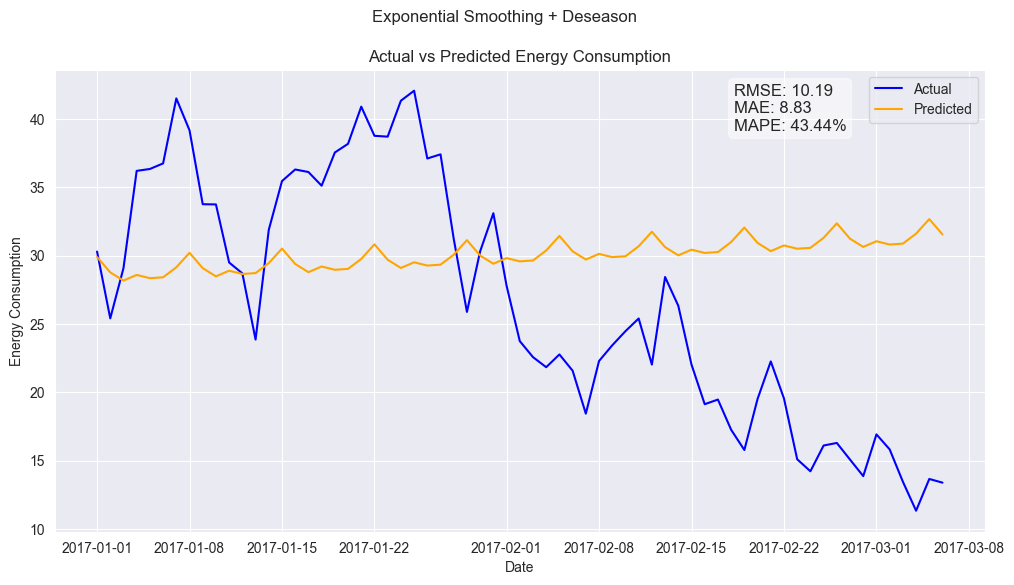

In [290]:
plt.figure(figsize=(12, 6))
plt.plot(df_logged["date"], df_logged["actual_kWh"], label="Actual", color="blue")
plt.plot(
    df_logged["date"], df_logged["predicted_kWh"], label="Predicted", color="orange"
)
rmse = np.sqrt(np.mean((df_logged["actual_kWh"] - df_logged["predicted_kWh"]) ** 2))
mae = np.mean(np.abs(df_logged["actual_kWh"] - df_logged["predicted_kWh"]))
mape = (
    np.mean(
        np.abs(
            (df_logged["actual_kWh"] - df_logged["predicted_kWh"])
            / df_logged["actual_kWh"]
        )
    )
    * 100
)
plt.text(
    0.73,
    0.97,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nMAPE: {mape:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.5),
)
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")
plt.suptitle("Exponential Smoothing + Deseason")
plt.legend()
plt.show()

**Interpretation**
- Actual vs predicted: close alignment shows the ETS captures the underlying trend; reported RMSE/MAE/MAPE quantify overall error.
- Systematic deviations around peaks/troughs indicate residual seasonality or nonlinear effects not captured by deseasonalization.
- The predictions are only a rising trend + weekly seasonality, so the model is not capturing any of the nonlinearities in the data.
- The long run seasonality was not addressed by the deseasonalization therefore predictions are worse in the later phase of the test set.

## 2. Prophet
### Method overview
Prophet is an additive forecasting model that explicitly models trend, multiple seasonalities and user-provided regressors (holidays or exogenous signals). It is robust to missing data and works well for business time series with changepoints.

In [351]:
run_id = "c99km3cg"

api = wandb.Api()
run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
config = run.config

table_artifact = [a for a in run.logged_artifacts() if "predictions" in a.name][0]
df_logged = table_artifact.get("predictions").get_dataframe()

wandb:   1 of 1 files downloaded.  


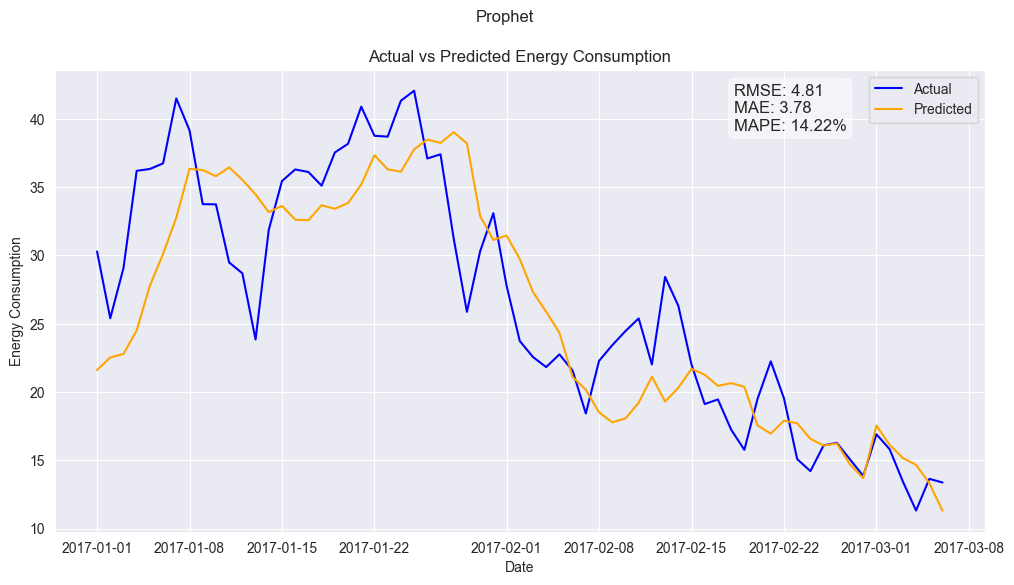

In [294]:
plt.figure(figsize=(12, 6))
plt.plot(df_logged["date"], df_logged["actual_kWh"], label="Actual", color="blue")
plt.plot(
    df_logged["date"], df_logged["predicted_kWh"], label="Predicted", color="orange"
)
rmse = np.sqrt(np.mean((df_logged["actual_kWh"] - df_logged["predicted_kWh"]) ** 2))
mae = np.mean(np.abs(df_logged["actual_kWh"] - df_logged["predicted_kWh"]))
mape = (
    np.mean(
        np.abs(
            (df_logged["actual_kWh"] - df_logged["predicted_kWh"])
            / df_logged["actual_kWh"]
        )
    )
    * 100
)
plt.text(
    0.73,
    0.97,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nMAPE: {mape:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.5),
)
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")
plt.suptitle("Prophet")
plt.legend()
plt.show()

In [295]:
parent_dir = os.path.dirname(os.getcwd())
train_df = pd.read_csv(
    os.path.join(parent_dir, config["data"]["train_path"]),
    index_col=0,
    parse_dates=True,
)
test_df = pd.read_csv(
    os.path.join(parent_dir, config["data"]["test_path"]), index_col=0, parse_dates=True
)

train_df, test_df = encode_features_prophet(
    train_df, test_df, resolution=config["data"]["resolution"]
)

regressor_cols = train_df.columns.difference(["ds", "y"])

m = prophet.Prophet(**config["model"])

for col in regressor_cols:
    m.add_regressor(col)

m.fit(train_df)
forecast = m.predict(train_df)

20:37:22 - cmdstanpy - INFO - Chain [1] start processing
20:37:22 - cmdstanpy - INFO - Chain [1] done processing


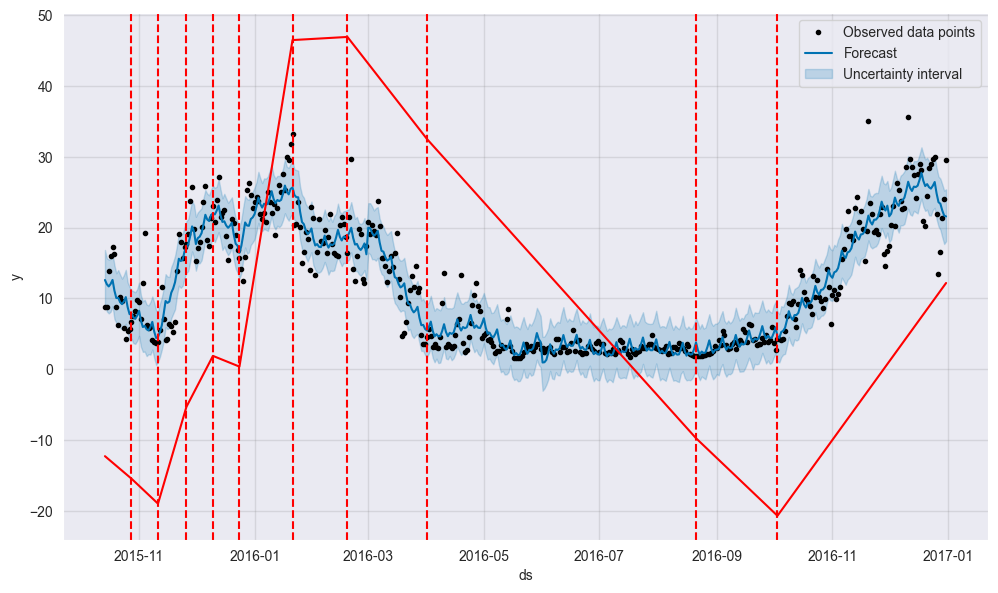

In [296]:
# plot the forecast
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)
plt.legend()
plt.show()

On the plot aboce we observe many regime changes in the trend, which is a sign that the model is trying to fit the nonlinearities in the data with a piecewise linear function. The weekly seasonality is captured well.

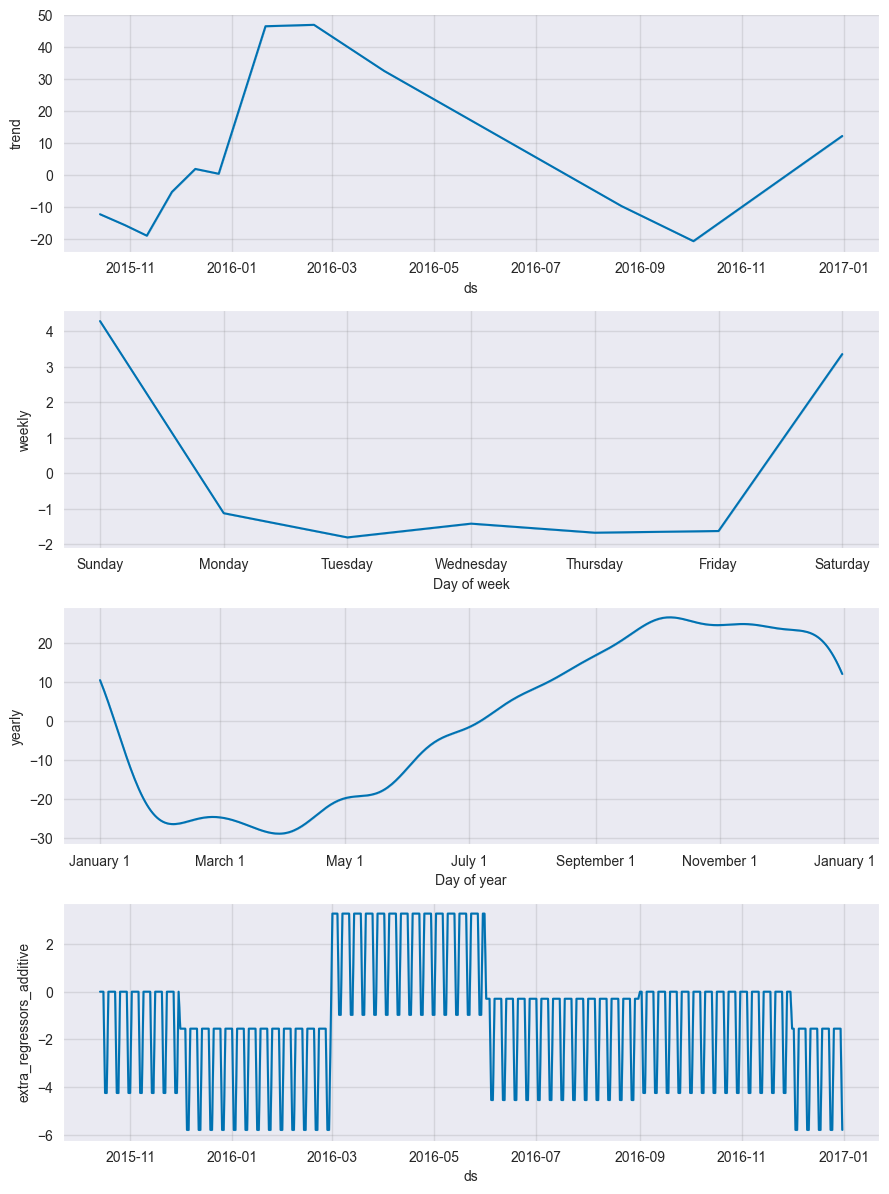

In [297]:
m.plot_components(forecast)
plt.show()

Trend is rather mixed with yearly seasonality, which is not surprising given the long-term structure of the data. The model captures the overall level and weekly pattern exhibiting higher demand on weekends. Yearly seasonality is reasonable with higher demand in the fall/winter months and lower in the spring/summer, which is consistent with heating demand patterns.

In [298]:
regressor_coefs = regressor_coefficients(m)
print("Regressor coefficients:")
regressor_coefs

Regressor coefficients:


,regressor,regressor_mode,center,coef_lower,coef,coef_upper
0,is_holiday_or_weekend_True,additive,0.0,-4.253838,-4.253838,-4.253838
1,season_spring,additive,0.0,3.281106,3.281106,3.281106
2,season_summer,additive,0.0,-0.296008,-0.296008,-0.296008
3,season_winter,additive,0.0,-1.552029,-1.552029,-1.552029


Additional regressive do not bring additional value as they are offset by the seasonality and trend components.

## 3. Deseasoned ARIMA(1,1,2)

## Method overview

ARIMA models combine autoregression (AR), differencing (I) to achieve stationarity, and moving average (MA). Here we fit ARIMA on the deseasonalized series so the model focuses on short-term autocorrelation and shocks. The model assumes linear relationships, therefore higher values of certain coefficients indicate stronger influence of past values or errors on the current prediction.

In [354]:
run_id = "i6nfjq31"

api = wandb.Api()
run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
config = run.config

table_artifact = [a for a in run.logged_artifacts() if "predictions" in a.name][0]
df_logged = table_artifact.get("predictions").get_dataframe()

wandb:   1 of 1 files downloaded.  


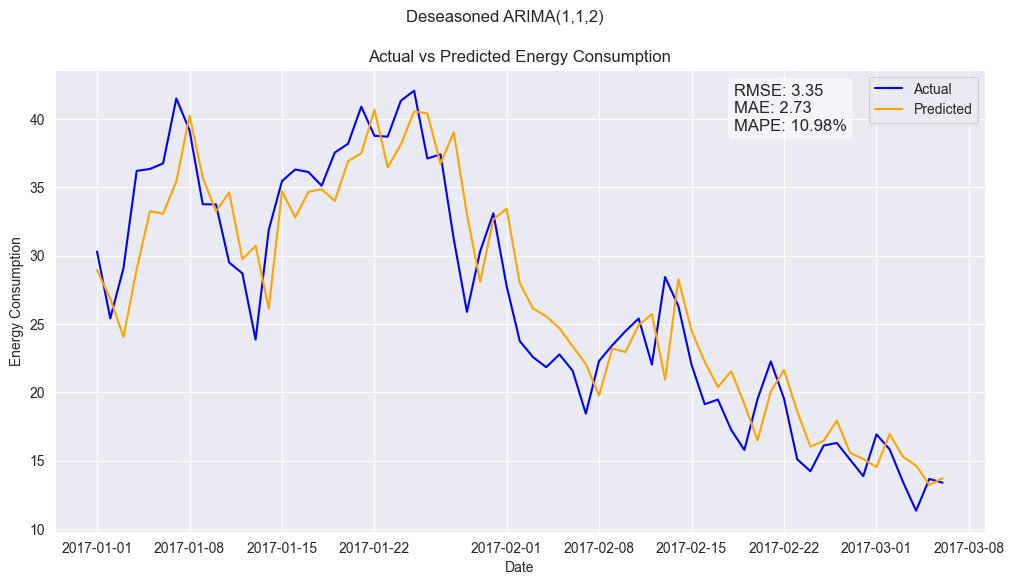

In [302]:
plt.figure(figsize=(12, 6))
plt.plot(df_logged["date"], df_logged["actual_kWh"], label="Actual", color="blue")
plt.plot(
    df_logged["date"], df_logged["predicted_kWh"], label="Predicted", color="orange"
)
rmse = np.sqrt(np.mean((df_logged["actual_kWh"] - df_logged["predicted_kWh"]) ** 2))
mae = np.mean(np.abs(df_logged["actual_kWh"] - df_logged["predicted_kWh"]))
mape = (
    np.mean(
        np.abs(
            (df_logged["actual_kWh"] - df_logged["predicted_kWh"])
            / df_logged["actual_kWh"]
        )
    )
    * 100
)
plt.text(
    0.73,
    0.97,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nMAPE: {mape:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.5),
)
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")
plt.suptitle("Deseasoned ARIMA(1,1,2)")
plt.legend()
plt.show()

In [303]:
train_df = pd.read_csv(
    os.path.join(parent_dir, config["data"]["train_path"]),
    index_col=0,
    parse_dates=True,
)
test_df = pd.read_csv(
    os.path.join(parent_dir, config["data"]["test_path"]), index_col=0, parse_dates=True
)
model_type = config["model"]["type"].lower()

seasonal_order = None
seasonal_period = config["model"].get("seasonal_period", 7)

deseasonalized_train, _, seasonal_cycle = seasonal_decompose_target(
    train_df,
    period=seasonal_period,
    model=config["model"].get("decompose_model", "additive"),
)
order = (1, 1, 2)
fit = ARIMA(deseasonalized_train, order=order, trend="n").fit()
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  445
Model:                 ARIMA(1, 1, 2)   Log Likelihood               -1075.695
Date:                Sun, 07 Jun 2026   AIC                           2159.391
Time:                        20:38:21   BIC                           2175.774
Sample:                    10-14-2015   HQIC                          2165.851
                         - 12-31-2016                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1987      0.103      1.931      0.053      -0.003       0.400
ma.L1         -0.3364      0.102     -3.288      0.001      -0.537      -0.136
ma.L2         -0.3438      0.054     -6.353      0.000      -0.450      -0.238
sigma2         7.4381      0.333     22.351      0.000       6.786       8.090
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               227.39
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.64   Skew:                            -0.19
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Estimated coefficients for moving average terms appear statistically significant, whereas autoregressive component's significance is less clear. Tests for heterskedasticity and autocorrelation of residuals suggest the variability was well explained. The Jarque-Bera test indicates residuals are not perfectly normal, likely due to remaining structure or heavy tails, but the model captures the main dynamics of the deseasonalized series.

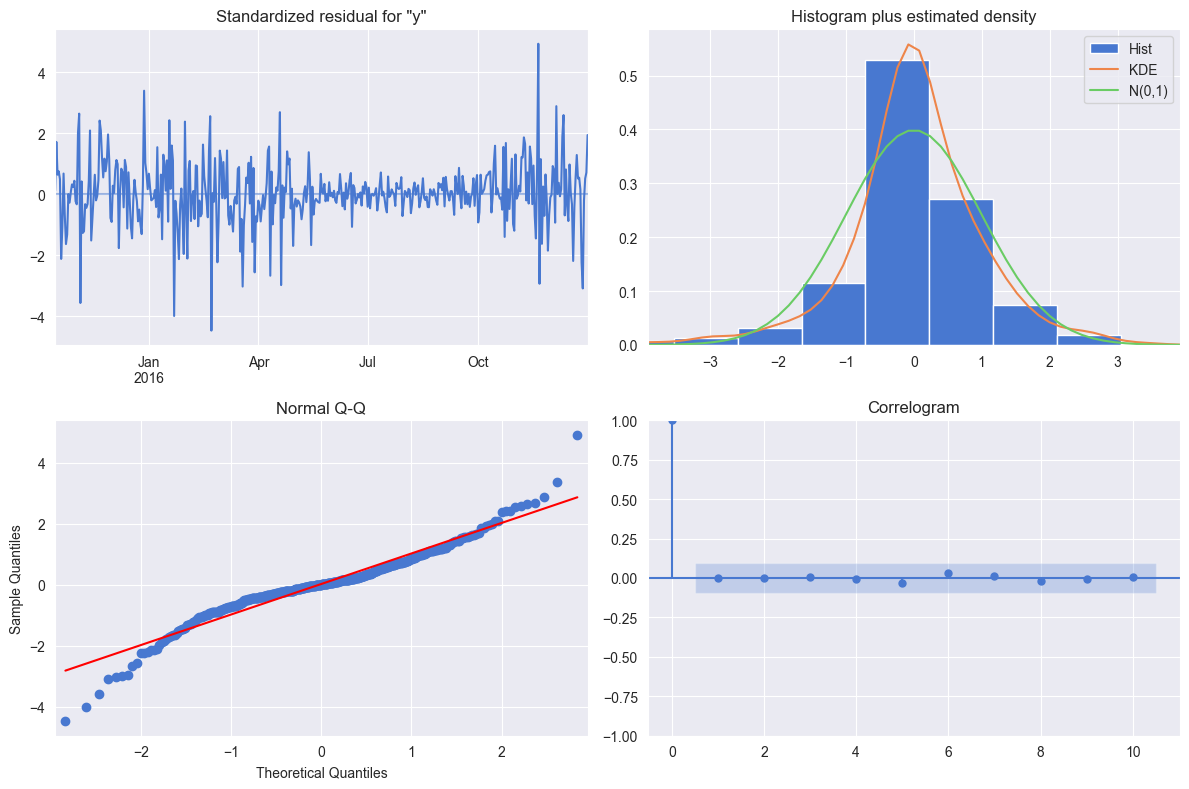

In [304]:
fit.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

The fit is not very satisfactory as the residuals exhibit fatter tails compared to a normal distribution. This is mainly due to the fact that seasonality was not fully captured by the simple deseasoning process. 

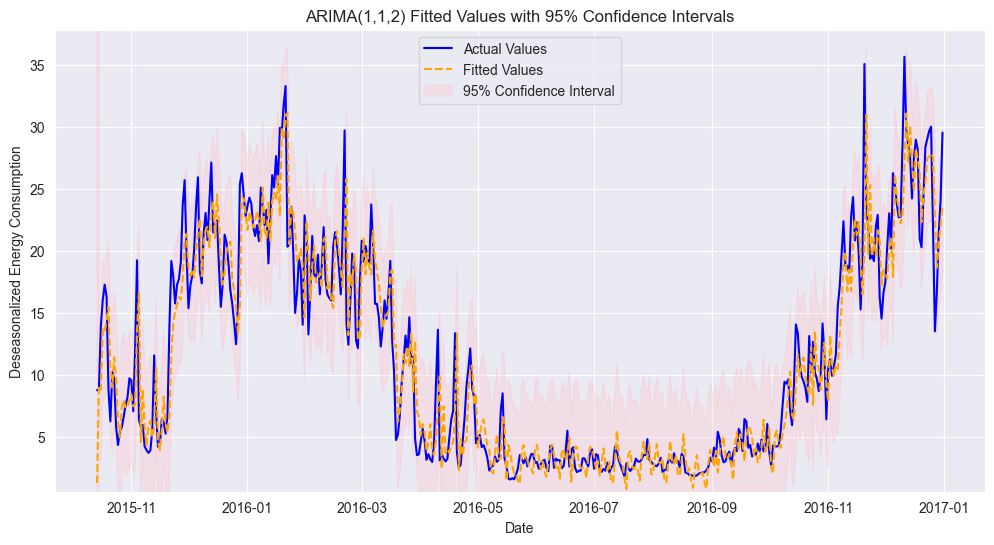

In [305]:
# plot fittedvalues with conf intervals
fittedvalues = (
    fit.fittedvalues
    + np.tile(seasonal_cycle, len(deseasonalized_train) // 7 + 1)[
        : len(deseasonalized_train)
    ]
)
conf_int = (
    fit.get_prediction().summary_frame()[["mean_ci_lower", "mean_ci_upper"]]
    + np.tile(
        np.tile(seasonal_cycle, len(deseasonalized_train) // 7 + 1)[
            : len(deseasonalized_train)
        ],
        (2, 1),
    ).T
)
plt.figure(figsize=(12, 6))
plt.plot(train_df.index, train_df["energy_demand"], label="Actual Values", color="blue")
plt.plot(
    fittedvalues.index,
    fittedvalues,
    label="Fitted Values",
    linestyle="--",
    color="orange",
)
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval",
)
plt.xlabel("Date")
plt.ylabel("Deseasonalized Energy Consumption")
plt.title("ARIMA(1,1,2) Fitted Values with 95% Confidence Intervals")
plt.legend()
plt.ylim(deseasonalized_train.min() * 1.1, deseasonalized_train.max() * 1.1)
plt.show()

**Interpretation:**
- ARIMA on deseasonalized data is useful to capture inertia and shock-reversion, but not ideal if seasonality or exogenous drivers materially affect peaks.

## 4. SARIMA(0,1,3)x(1,1,1,7)
### Method overview
SARIMA extends ARIMA with seasonal AR and MA terms to capture repeating patterns at a fixed period.

In [356]:
run_id = "znxzbbdy"

api = wandb.Api()
run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
config = run.config

table_artifact = [a for a in run.logged_artifacts() if "predictions" in a.name][0]
df_logged = table_artifact.get("predictions").get_dataframe()

wandb:   1 of 1 files downloaded.  


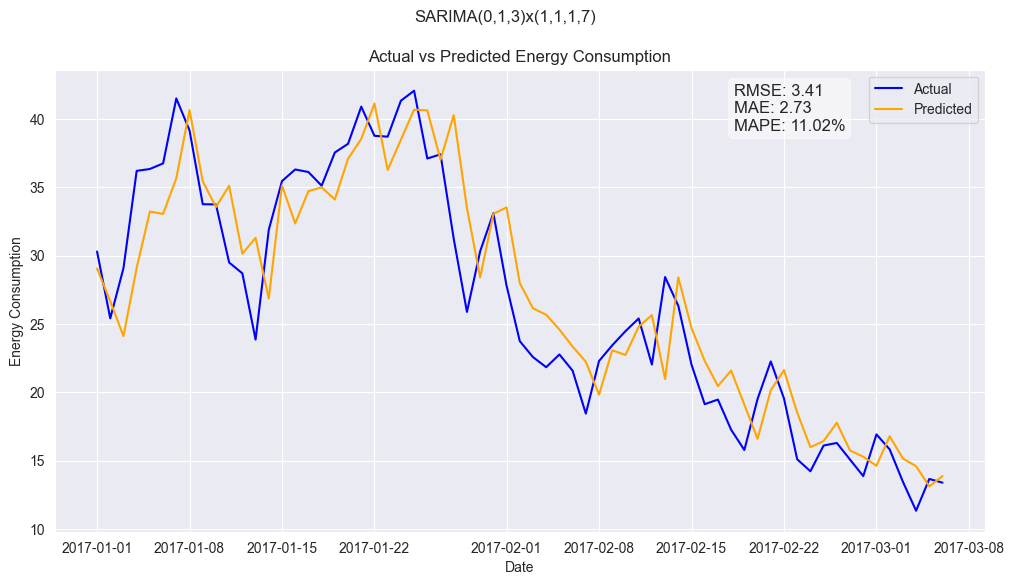

In [309]:
plt.figure(figsize=(12, 6))
plt.plot(df_logged["date"], df_logged["actual_kWh"], label="Actual", color="blue")
plt.plot(
    df_logged["date"], df_logged["predicted_kWh"], label="Predicted", color="orange"
)
rmse = np.sqrt(np.mean((df_logged["actual_kWh"] - df_logged["predicted_kWh"]) ** 2))
mae = np.mean(np.abs(df_logged["actual_kWh"] - df_logged["predicted_kWh"]))
mape = (
    np.mean(
        np.abs(
            (df_logged["actual_kWh"] - df_logged["predicted_kWh"])
            / df_logged["actual_kWh"]
        )
    )
    * 100
)
plt.text(
    0.73,
    0.97,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nMAPE: {mape:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.5),
)
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")
plt.suptitle("SARIMA(0,1,3)x(1,1,1,7)")
plt.legend()
plt.show()

In [310]:
train_df = pd.read_csv(
    os.path.join(parent_dir, config["data"]["train_path"]),
    index_col=0,
    parse_dates=True,
)
test_df = pd.read_csv(
    os.path.join(parent_dir, config["data"]["test_path"]), index_col=0, parse_dates=True
)
model_type = config["model"]["type"].lower()

trend = config["model"].get("trend", "c")
order = (0, 1, 3)
sorder = (1, 1, 1, 7)
fit = SARIMAX(
    endog=train_df[["energy_demand"]].copy(),
    exog=None,
    order=order,
    seasonal_order=sorder,
    trend=trend,
    enforce_stationarity=config["model"].get("enforce_stationarity", True),
    enforce_invertibility=config["model"].get("enforce_invertibility", True),
).fit(disp=False)
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                       energy_demand   No. Observations:                  445
Model:             SARIMAX(0, 1, 3)x(1, 1, [1], 7)   Log Likelihood               -1046.266
Date:                             Sun, 07 Jun 2026   AIC                           2106.532
Time:                                     20:39:47   BIC                           2134.913
Sample:                                 10-14-2015   HQIC                          2117.743
                                      - 12-31-2016                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0026      0.003      0.837      0.403      -0.003       0.009
ma.L1         -0.1544      0.035     -4.385      0.000      -0.223      -0.085
ma.L2         -0.3762      0.045     -8.278      0.000      -0.465      -0.287
ma.L3         -0.0721      0.043     -1.664      0.096      -0.157       0.013
ar.S.L7        0.0040      0.002      2.172      0.030       0.000       0.008
ma.S.L7       -1.0000     31.934     -0.031      0.975     -63.590      61.590
sigma2         7.5034    239.558      0.031      0.975    -462.021     477.028
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               234.00
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.63   Skew:                            -0.15
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.62
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Again, similar to deseasoned ARIMA, the moving average terms are significant, but the autoregressive terms are not. The seasonal AR and MA terms are also significant, confirming the presence of weekly seasonality. However, the residuals still show some autocorrelation and heteroskedasticity, suggesting that there may be remaining structure or volatility clustering not captured by the model.

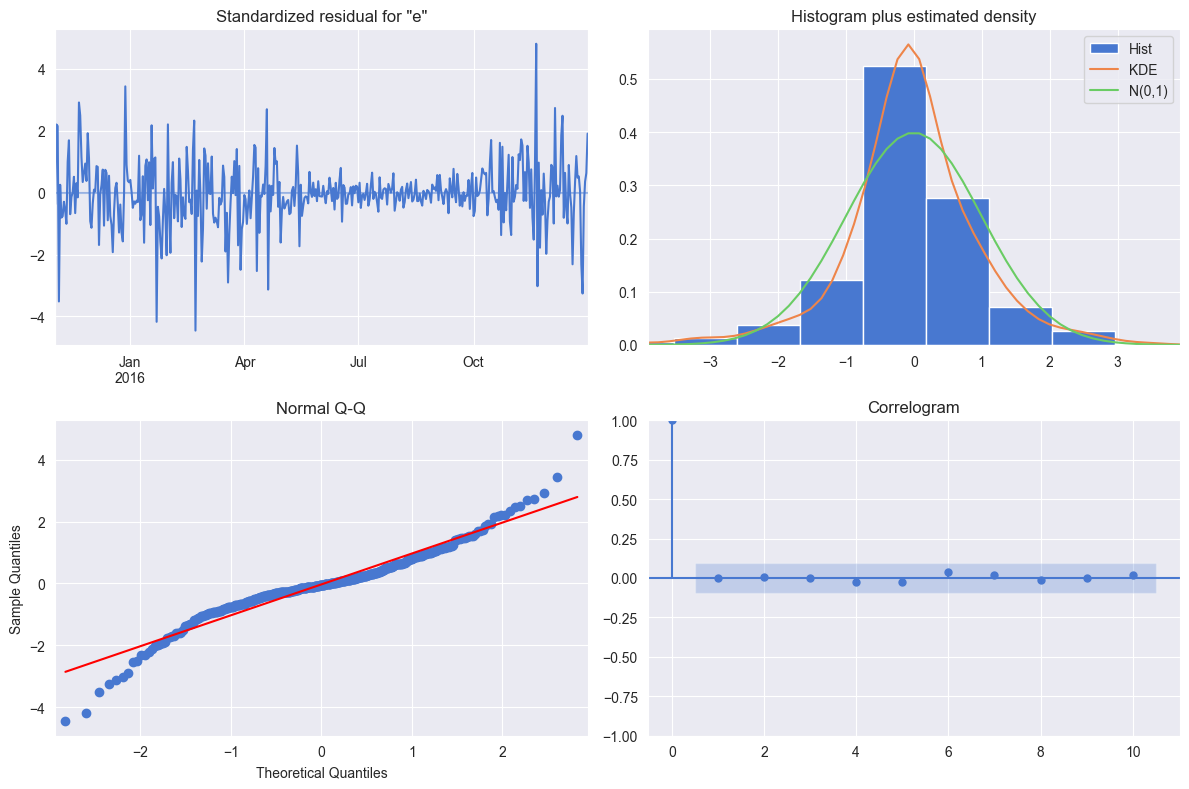

In [311]:
fit.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

Residuals show remaining seasonal structure due to significant regime changes observed in the data, which are not fully captured by the SARIMA model. The model captures the main weekly seasonality and some of the short-term dynamics, but the changing trend and potential nonlinearities lead to residual patterns that suggest further model refinement or additional features may be needed for better fit.

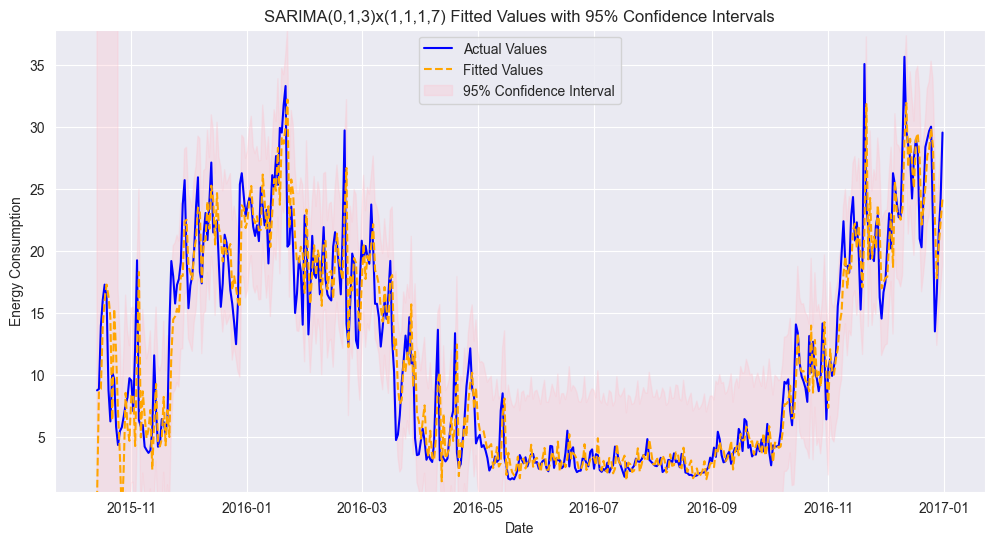

In [312]:
# plot fittedvalues with conf intervals
fittedvalues = fit.fittedvalues
conf_int = fit.get_prediction().summary_frame()[["mean_ci_lower", "mean_ci_upper"]]
plt.figure(figsize=(12, 6))
plt.plot(train_df.index, train_df["energy_demand"], label="Actual Values", color="blue")
plt.plot(
    fittedvalues.index,
    fittedvalues,
    label="Fitted Values",
    linestyle="--",
    color="orange",
)
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval",
)
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.title("SARIMA(0,1,3)x(1,1,1,7) Fitted Values with 95% Confidence Intervals")
plt.legend()
plt.ylim(deseasonalized_train.min() * 1.1, deseasonalized_train.max() * 1.1)
plt.show()

## 5. SARIMAX(0,1,3)x(0,1,1,7)
### Method overview
SARIMAX additionally supports exogenous regressors. These are standard statistical approaches for seasonal time series and provide interpretable coefficients and prediction intervals.

In [359]:
run_id = "fwg0uzd9"

api = wandb.Api()
run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
config = run.config

table_artifact = [a for a in run.logged_artifacts() if "predictions" in a.name][0]
df_logged = table_artifact.get("predictions").get_dataframe()

wandb:   1 of 1 files downloaded.  


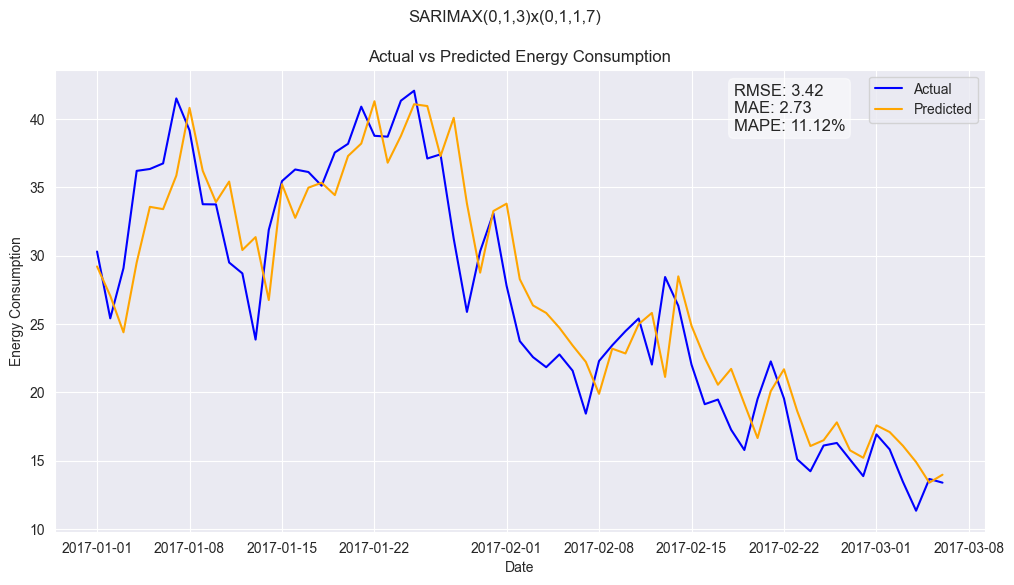

In [316]:
plt.figure(figsize=(12, 6))
plt.plot(df_logged["date"], df_logged["actual_kWh"], label="Actual", color="blue")
plt.plot(
    df_logged["date"], df_logged["predicted_kWh"], label="Predicted", color="orange"
)
rmse = np.sqrt(np.mean((df_logged["actual_kWh"] - df_logged["predicted_kWh"]) ** 2))
mae = np.mean(np.abs(df_logged["actual_kWh"] - df_logged["predicted_kWh"]))
mape = (
    np.mean(
        np.abs(
            (df_logged["actual_kWh"] - df_logged["predicted_kWh"])
            / df_logged["actual_kWh"]
        )
    )
    * 100
)
plt.text(
    0.73,
    0.97,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nMAPE: {mape:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.5),
)
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")
plt.suptitle("SARIMAX(0,1,3)x(0,1,1,7)")
plt.legend()
plt.show()

In [317]:
train_df = pd.read_csv(
    os.path.join(parent_dir, config["data"]["train_path"]),
    index_col=0,
    parse_dates=True,
)
test_df = pd.read_csv(
    os.path.join(parent_dir, config["data"]["test_path"]), index_col=0, parse_dates=True
)
model_type = config["model"]["type"].lower()

train_encoded, test_encoded = encode_features_arima(
    train_df, test_df, resolution=config["data"]["resolution"]
)
exog_train = train_encoded.drop(columns=["energy_demand"])

trend = config["model"].get("trend", "c")
order = (0, 1, 3)
sorder = (0, 1, 1, 7)
fit = SARIMAX(
    endog=train_df[["energy_demand"]].copy(),
    exog=exog_train,
    order=order,
    seasonal_order=sorder,
    trend=trend,
    enforce_stationarity=config["model"].get("enforce_stationarity", True),
    enforce_invertibility=config["model"].get("enforce_invertibility", True),
).fit(disp=False)
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                       energy_demand   No. Observations:                  445
Model:             SARIMAX(0, 1, 3)x(0, 1, [1], 7)   Log Likelihood               -1046.453
Date:                             Sun, 07 Jun 2026   AIC                           2112.906
Time:                                     20:40:05   BIC                           2153.450
Sample:                                 10-14-2015   HQIC                          2128.921
                                      - 12-31-2016                                         
Covariance Type:                               opg                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
intercept                      0.0037      0.003      1.172      0.241      -0.003       0.010
is_holiday_or_weekend_True  9.437e-07   1.01e-06      0.936      0.349   -1.03e-06    2.92e-06
season_spring                  2.5162      4.537      0.555      0.579      -6.377      11.409
season_summer                  1.1165      4.687      0.238      0.812      -8.070      10.303
season_winter                  0.0960      2.304      0.042      0.967      -4.419       4.611
ma.L1                         -0.1535      0.034     -4.517      0.000      -0.220      -0.087
ma.L2                         -0.3722      0.046     -8.113      0.000      -0.462      -0.282
ma.L3                         -0.0639      0.044     -1.443      0.149      -0.151       0.023
ma.S.L7                       -0.9996      2.135     -0.468      0.640      -5.184       3.185
sigma2                         7.5302     16.039      0.470      0.639     -23.905      38.965
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               230.35
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.63   Skew:                            -0.12
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.13e+18. Standard errors may be unstable.
"""

The fit is similar to the SARIMA model, but the exogenous regressors allow us to identify specific drivers of demand. Positive coefficients indicate factors that increase demand (e.g., colder temperatures, business days), while negative coefficients indicate factors that decrease demand (e.g., warmer temperatures, holidays). These do not add significant predictive power beyond the seasonal and trend components, but they provide interpretability by quantifying the impact of external factors on demand.

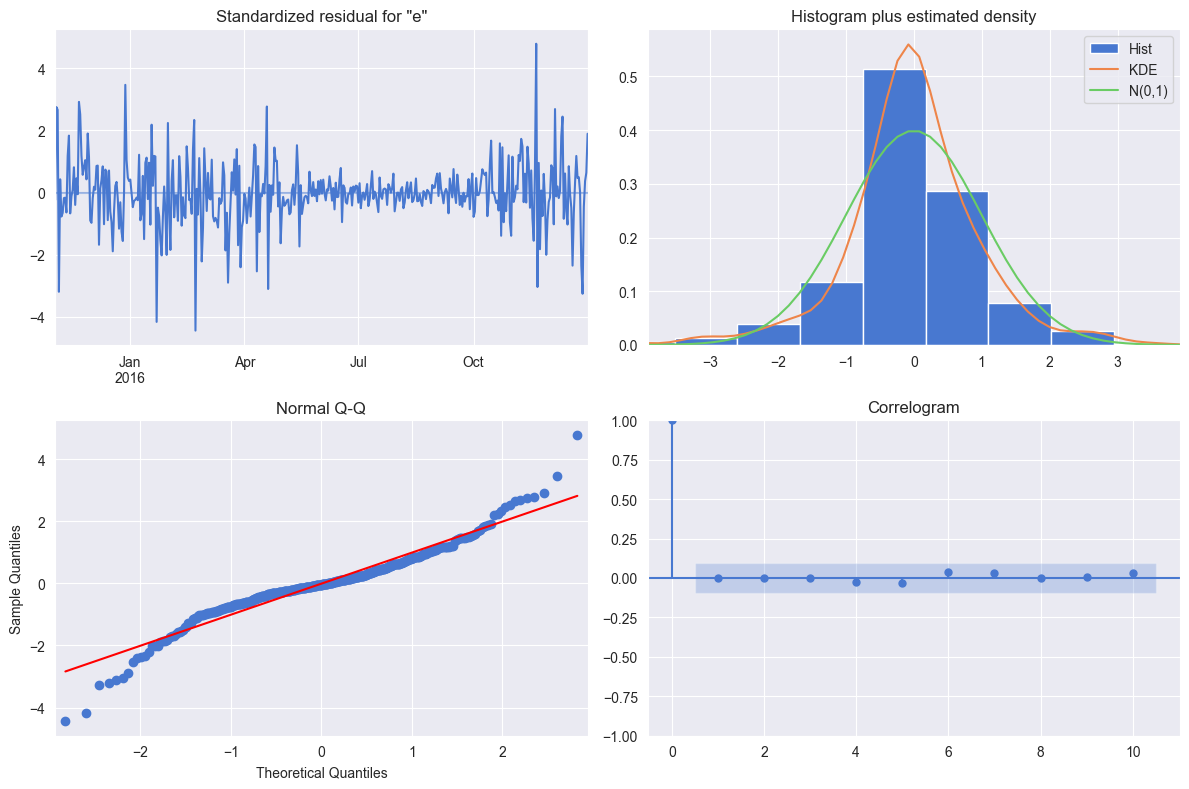

In [318]:
fit.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

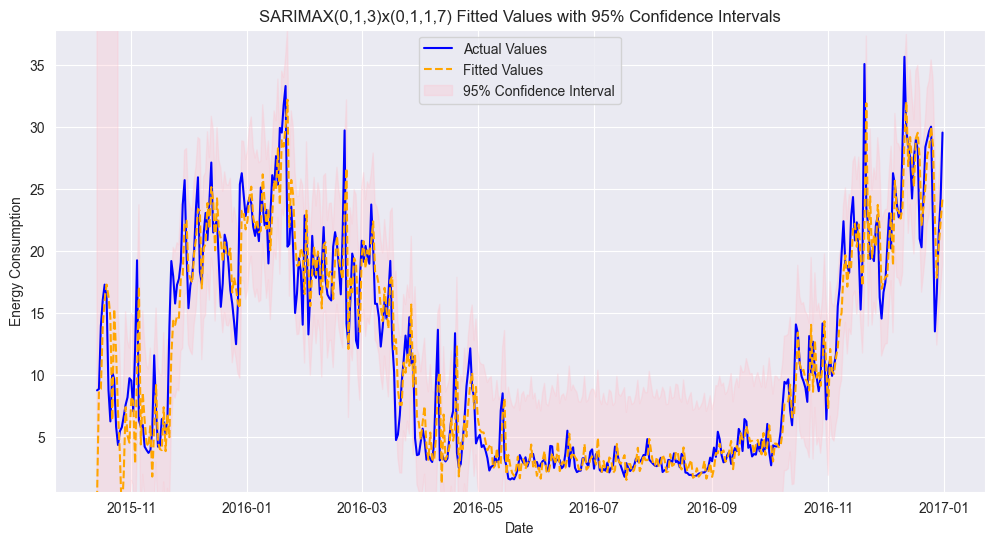

In [319]:
# plot fittedvalues with conf intervals
fittedvalues = fit.fittedvalues
conf_int = fit.get_prediction().summary_frame()[["mean_ci_lower", "mean_ci_upper"]]
plt.figure(figsize=(12, 6))
plt.plot(train_df.index, train_df["energy_demand"], label="Actual Values", color="blue")
plt.plot(
    fittedvalues.index,
    fittedvalues,
    label="Fitted Values",
    linestyle="--",
    color="orange",
)
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval",
)
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.title("SARIMAX(0,1,3)x(0,1,1,7) Fitted Values with 95% Confidence Intervals")
plt.legend()
plt.ylim(deseasonalized_train.min() * 1.1, deseasonalized_train.max() * 1.1)
plt.show()

## 6. Attention LSTM
## Method overview — Attention LSTM

The Attention LSTM is a neural sequence model that augments regular LSTM units with an attention mechanism to weight past time steps. It captures nonlinear interactions and temporal importance.

In [361]:
run_id = "n3viomoq"

api = wandb.Api()
run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
config = run.config

artifact = api.artifact(f'{ENTITY}/{PROJECT}/trained_model_{config["run_name"]}:latest')
artifact_dir = artifact.download()

table_artifact = [a for a in run.logged_artifacts() if "predictions" in a.name][0]
df_logged = table_artifact.get("predictions").get_dataframe()

scaler = joblib.load(os.path.join(artifact_dir, "scaler.joblib"))
state_dict = torch.load(os.path.join(artifact_dir, "model.pth"), map_location="cpu")

parent_dir = os.path.dirname(os.getcwd())
train_df = load_data(os.path.join(parent_dir, config["data"]["train_path"]))
test_df = load_data(os.path.join(parent_dir, config["data"]["test_path"]))

train_df, test_df = encode_features(
    train_df, test_df, resolution=config["data"]["resolution"]
)
train_df, test_df, _ = scale_data(train_df, test_df)

feat_names = train_df.columns

lags = config["data"]["lags"]
_, _, _, Xp, Xf, _ = create_sequences(
    train_df, test_df, k=lags[-1], resolution=config["data"]["resolution"]
)

wandb:   2 of 2 files downloaded.  
wandb:   1 of 1 files downloaded.  


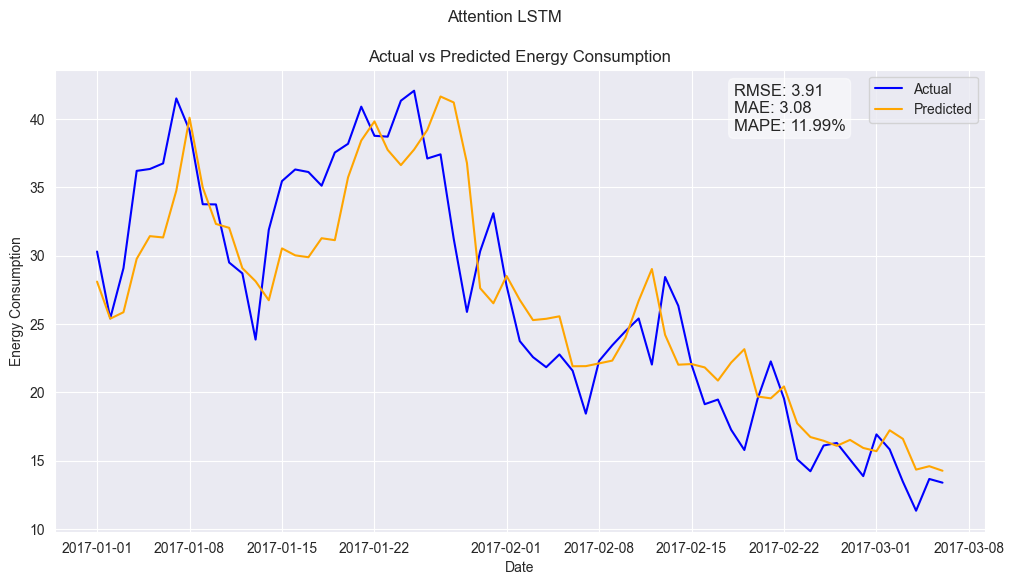

In [323]:
plt.figure(figsize=(12, 6))
plt.plot(df_logged["date"], df_logged["actual_kWh"], label="Actual", color="blue")
plt.plot(
    df_logged["date"], df_logged["predicted_kWh"], label="Predicted", color="orange"
)
rmse = np.sqrt(np.mean((df_logged["actual_kWh"] - df_logged["predicted_kWh"]) ** 2))
mae = np.mean(np.abs(df_logged["actual_kWh"] - df_logged["predicted_kWh"]))
mape = (
    np.mean(
        np.abs(
            (df_logged["actual_kWh"] - df_logged["predicted_kWh"])
            / df_logged["actual_kWh"]
        )
    )
    * 100
)
plt.text(
    0.73,
    0.97,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nMAPE: {mape:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.5),
)
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")
plt.suptitle("Attention LSTM")
plt.legend()
plt.show()

In [324]:
# helper functions
def rescale_val(scaler, val, n_features, is_contribution=False):
    """Helper to map scaled values back to kWh."""
    dummy = np.zeros((1, n_features))
    dummy[0, 0] = val
    rescaled = scaler.inverse_transform(dummy)[0, 0]
    if is_contribution:
        zero_dummy = np.zeros((1, n_features))
        return rescaled - scaler.inverse_transform(zero_dummy)[0, 0]
    return rescaled


def run_counterfactual_scenarios(
    model, Xp, Xf, scaler, past_names, future_names, sample_idx=25
):
    """
    Simulates various what-if scenarios for a single instance to test model sensitivity.
    """
    model.eval()
    n_features = scaler.n_features_in_

    temp_idx = past_names.index("temperature")
    holiday_idx = future_names.index("is_holiday_or_weekend_True")

    orig_xp = torch.tensor(Xp[sample_idx : sample_idx + 1]).float()
    orig_xf = torch.tensor(Xf[sample_idx : sample_idx + 1]).float()

    with torch.no_grad():
        base_pred = rescale_val(scaler, model(orig_xp, orig_xf).item(), n_features)

    scenarios = {}

    temp_idx = list(feat_names).index("temperature")

    temp_range = scaler.data_range_[temp_idx]
    physical_delta = 0.33 * temp_range
    print(f"training temp range: {temp_range:.2f}°C")
    print(f"0.33 shift : {physical_delta:.2f}°C")

    # Scenario 1: colder last 2 days (-0.33 scaled shift - about -10C)
    xp_cold = orig_xp.clone()
    xp_cold[:, :, temp_idx] -= 0.33
    with torch.no_grad():
        scenarios["Cold snap (-10C)"] = rescale_val(
            scaler, model(xp_cold, orig_xf).item(), n_features
        )

    # Scenario 2: Heat wave
    xp_heat = orig_xp.clone()
    xp_heat[:, :, temp_idx] += 0.33
    with torch.no_grad():
        scenarios["Heat wave (+10C)"] = rescale_val(
            scaler, model(xp_heat, orig_xf).item(), n_features
        )

    # Scenario 3: Holiday Flip (If it was a holiday, make it a workday and opposite)
    xf_flip = orig_xf.clone()
    is_holiday = xf_flip[0, 0, holiday_idx].item() > 0.5
    xf_flip[0, 0, holiday_idx] = 0.0 if is_holiday else 1.0
    label = "Normal Day -> Holiday" if not is_holiday else "Holiday -> Normal Day"
    with torch.no_grad():
        scenarios[label] = rescale_val(
            scaler, model(orig_xp, xf_flip).item(), n_features
        )

    names = list(scenarios.keys())
    values = list(scenarios.values())

    plt.figure(figsize=(10, 6))
    bars = plt.barh(names, values, color=["powderblue", "lightsalmon", "palegreen"])
    plt.axvline(base_pred, color="black", linestyle="--", label="Baseline forecast")
    plt.bar_label(bars, padding=3, fmt="%.2f kWh")
    plt.title(f"Counterfactual Analysis: what-if scenarios for sample {sample_idx}")
    plt.xlabel("Predicted energy demand (kWh)")
    plt.legend()
    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.show()

    return scenarios

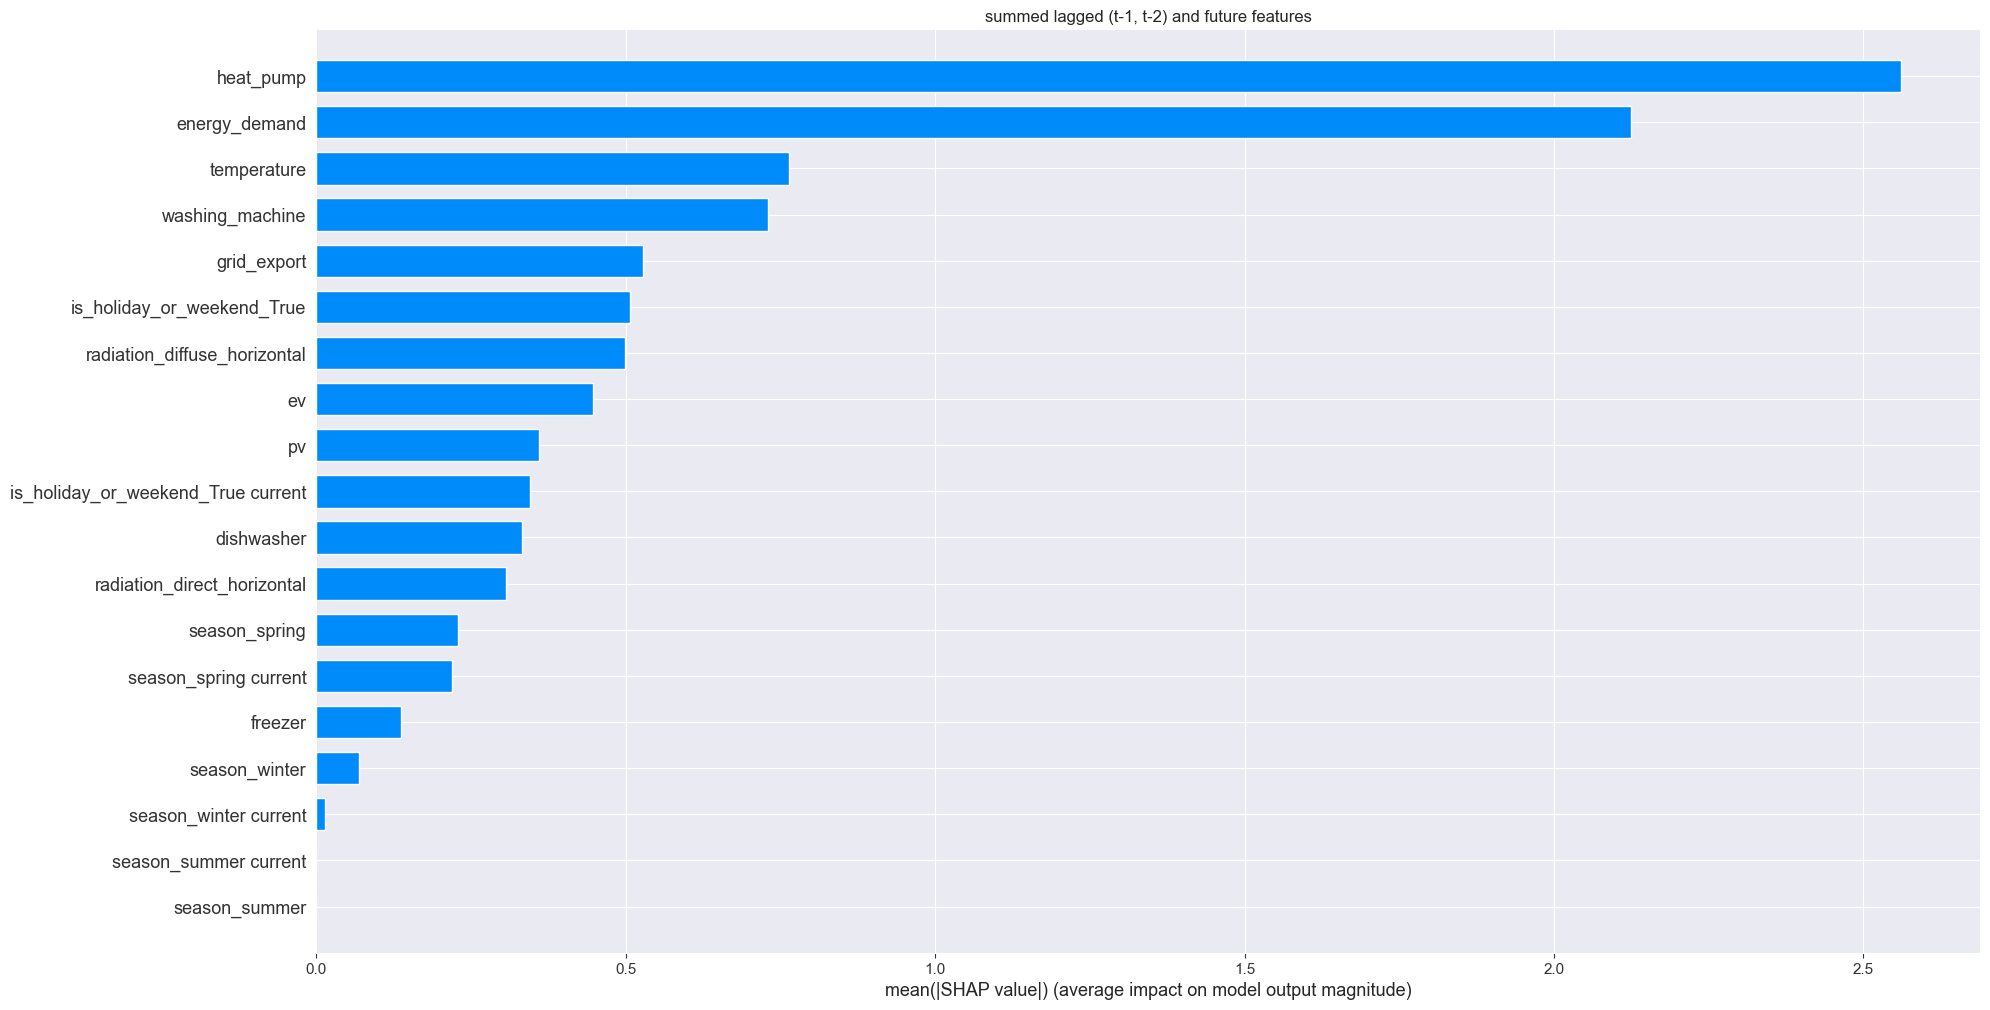

In [325]:
model = LSTMAttentionModel(
    input_size=Xp.shape[1],
    n_past_features=Xp.shape[2],
    n_future_features=Xf.shape[2],
    **config["model"]["network_params"],
)
model.load_state_dict(state_dict)
model.eval()

n_features = scaler.n_features_in_
future_feat_names = feat_names[-4:].tolist()
past_feat_names = feat_names[:-4].tolist()
all_feature_names = feat_names.tolist() + [
    f + " current" for f in future_feat_names
]  # past features for both lags + future only
rescale_factor = scaler.data_range_[0]

bg_p, bg_f = torch.tensor(Xp).float(), torch.tensor(Xf).float()
explainer = shap.GradientExplainer(model, [bg_p, bg_f])

test_p, test_f = torch.tensor(Xp).float(), torch.tensor(Xf).float()
shap_values = explainer.shap_values([test_p, test_f])

past_shap_summed = (shap_values[0][:, -1, :] + shap_values[0][:, -2, :]).reshape(
    len(Xp), -1
)  # lag1+lag2
future_shap = shap_values[1].reshape(len(Xf), -1)

global_shap_kwh = (
    np.concatenate([past_shap_summed, future_shap], axis=1) * rescale_factor
)
global_data = np.concatenate([Xp[:, -1, :], Xf[:, 0, :]], axis=1)

plt.Figure(figsize=(20, 10))
shap.summary_plot(
    global_shap_kwh,
    global_data,
    feature_names=all_feature_names,
    plot_type="bar",
    show=False,
    plot_size=(20, 10),
)
plt.title("summed lagged (t-1, t-2) and future features")
plt.show()

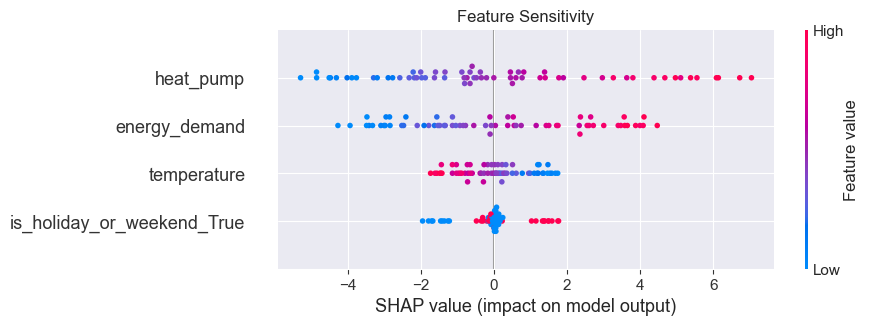

In [326]:
target_f = [
    "energy_demand",
    "heat_pump",
    "temperature",
    "is_holiday_or_weekend_True",
]
target_idx = [all_feature_names.index(f) for f in target_f if f in all_feature_names]
exp_beeswarm = shap.Explanation(
    values=global_shap_kwh[:, target_idx],
    data=global_data[:, target_idx],
    feature_names=target_f,
)
shap.plots.beeswarm(exp_beeswarm, show=False)
plt.title("Feature Sensitivity")
plt.show()

The heat pump feature shows a strong positive SHAP value, indicating that higher heat pump usage is associated with increased energy demand. This makes intuitive sense, as heat pumps consume electricity to operate. The temperature feature has a negative SHAP value, suggesting that higher temperatures lead to lower energy demand, likely due to reduced heating needs. The is_holiday_or_weekend_True feature has a positive SHAP value, indicating that holidays and weekends are associated with increased energy demand, possibly due to more people being at home and using appliances.

Avg attention [0.311299   0.68870103]


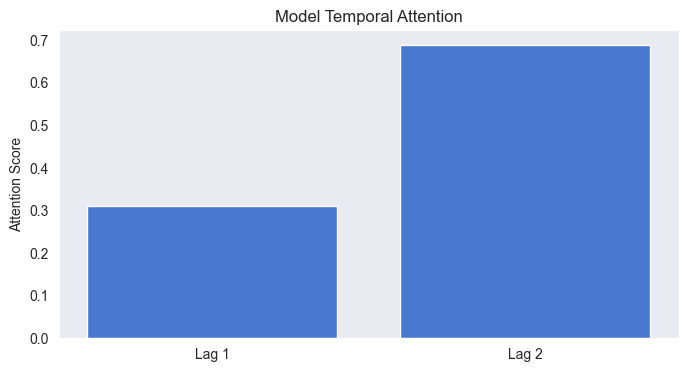

In [327]:
# attention
with torch.no_grad():
    _, weights = model(test_p, test_f, return_attn=True)
avg_attention = weights.squeeze().mean(dim=0).cpu().numpy()

plt.figure(figsize=(8, 4))
plt.bar([f"Lag {i+1}" for i in range(len(avg_attention))], avg_attention)
plt.title("Model Temporal Attention")
plt.grid()
print("Avg attention", avg_attention)
plt.ylabel("Attention Score")
plt.show()

Model's attention weights indicate clearly that the most recent time step is the most important for the prediction. This is consistent with the intuition that recent values are more predictive of the next time step in a time series. The attention mechanism allows the model to focus on the most relevant parts of the input sequence, which can improve forecasting performance compared to a standard LSTM that treats all past time steps equally.

Now, we visualize prediction for the 1st time step and investigate the local impact of main drivers of the prediction using SHAP values.


Instance 0


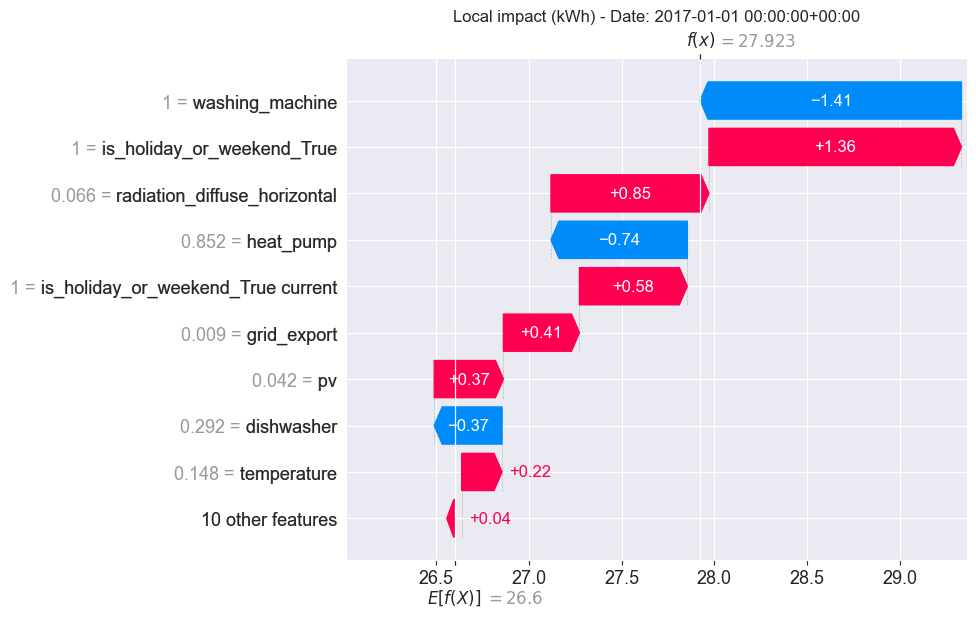

,0
date,2017-01-01 00:00:00+00:00
actual_kWh,30.293125
predicted_kWh,28.09294
error,2.200185
norm_energy_demand,0.820711
norm_dishwasher,0.292096
norm_ev,0.122902
norm_freezer,0.0
norm_grid_export,0.009274
norm_heat_pump,0.851559


In [328]:
# individual predicitons
with torch.no_grad():
    raw_base = model(bg_p, bg_f).mean().item()
kwh_base = rescale_val(scaler, raw_base, n_features)

for idx in [0]:
    print(f"\nInstance {idx}")
    row = df_logged.iloc[idx]

    exp_instance = shap.Explanation(
        values=global_shap_kwh[idx],
        base_values=kwh_base,
        data=global_data[idx],
        feature_names=all_feature_names,
    )
    plt.figure(figsize=(12, 5))
    shap.plots.waterfall(exp_instance, show=False)
    plt.title(f"Local impact (kWh) - Date: {row['date']}")
    plt.show()
    instance_df = df_logged.iloc[[idx]].copy()
    for f_name, f_val in zip(all_feature_names, global_data[idx]):
        instance_df[f"norm_{f_name}"] = f_val
    display(instance_df.T)

For this specific time step (January 1, 2017—New Year's Day holiday), the model predicts a higher-than-average grid import of 28.73 kWh.
The main reasons for this high import are the fact that it is a holiday/weekend, combined with poor weather/low solar conditions (low radiation, low PV output) which prevents self-generation. This extra demand is only partially mitigated by the current operational states of the washing machine and heat pump.

training temp range: 29.86°C
0.33 shift : 9.86°C


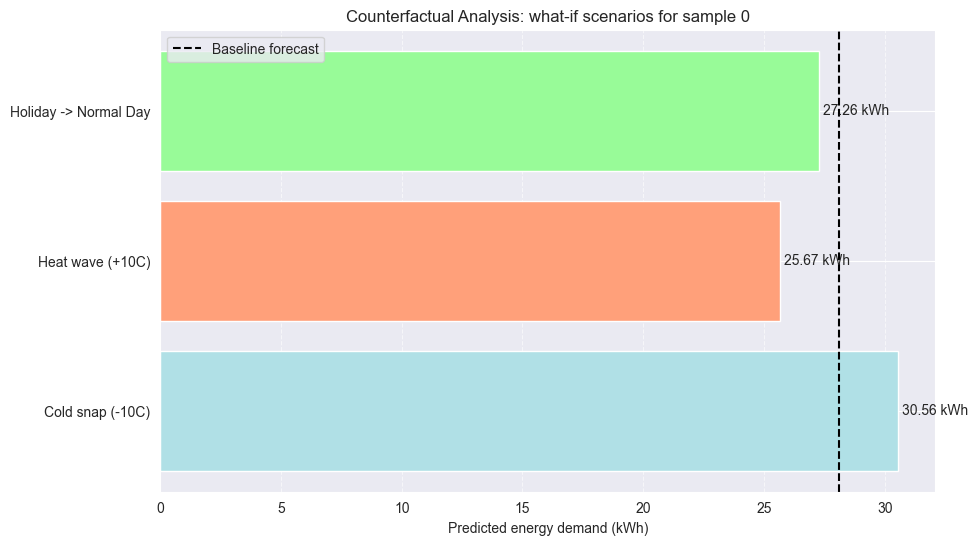

{'Cold snap (-10C)': np.float64(30.564592457077794),
 'Heat wave (+10C)': np.float64(25.672090301277194),
 'Holiday -> Normal Day': np.float64(27.26166556100491)}

In [329]:
# counterfactual
run_counterfactual_scenarios(
    model, Xp, Xf, scaler, past_feat_names, future_feat_names, sample_idx=0
)

Model's behavior is consistent with domain knowledge: holidays and poor weather conditions lead to higher grid imports due to reduced self-generation and increased demand. The SHAP values provide a clear explanation of how each feature contributes to the prediction, which enhances the interpretability of the model and builds trust in its forecasts.

## 7. Encoder-decoder LSTM
### Method overview
Encoder-decoder LSTM is a sequence-to-sequence model that uses an encoder to process the input sequence and a decoder to generate the forecast give additional information on the current time step features without leaking those which would not have been available at prediction time. This architecture allows for more flexible modeling of temporal dependencies and can capture complex patterns in the data.

In [363]:
run_id = "s6hiczdx"

api = wandb.Api()
run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
config = run.config

artifact = api.artifact(
    f'{ENTITY}/{PROJECT}/trained_model_{config["wandb"]["run_name"]}:latest'
)
artifact_dir = artifact.download()

table_artifact = [a for a in run.logged_artifacts() if "predictions" in a.name][0]
df_logged = table_artifact.get("predictions").get_dataframe()

scaler = joblib.load(os.path.join(artifact_dir, "scaler.joblib"))
model = load_model(os.path.join(artifact_dir, "lstm_enc_dec.keras"))

parent_dir = os.path.dirname(os.getcwd())
train_df = load_data(os.path.join(parent_dir, config["data"]["train_path"]))
test_df = load_data(os.path.join(parent_dir, config["data"]["test_path"]))

train_df, test_df = encode_features(
    train_df, test_df, resolution=config["data"]["resolution"]
)
train_df, test_df, _ = scale_data(train_df, test_df)

feat_names = train_df.columns

lags = config["data"]["lags"]
_, _, _, Xp, Xf, _ = create_sequences(
    train_df, test_df, k=lags[-1], resolution=config["data"]["resolution"]
)

wandb:   2 of 2 files downloaded.  
wandb:   1 of 1 files downloaded.  


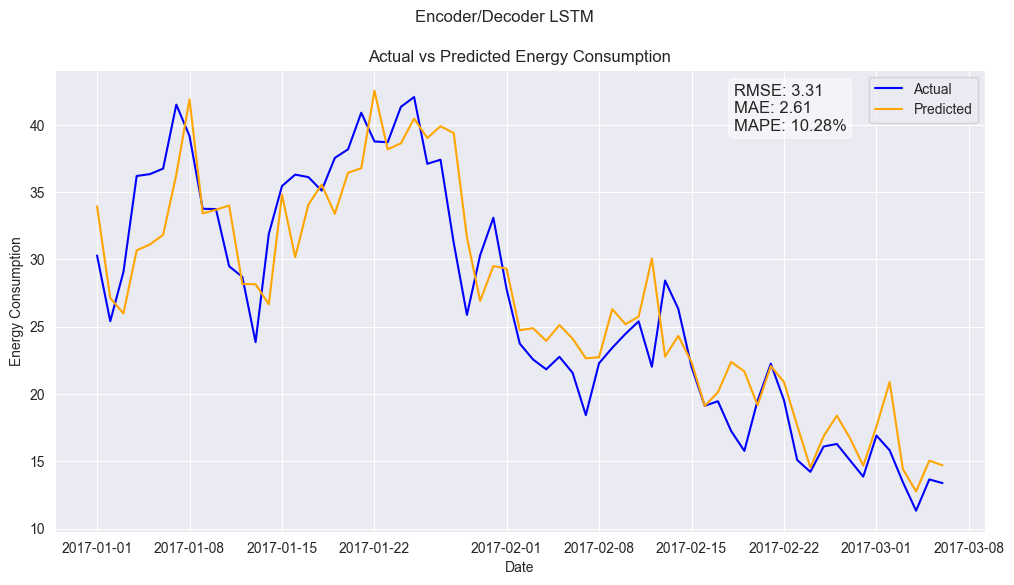

In [333]:
plt.figure(figsize=(12, 6))
plt.plot(df_logged["date"], df_logged["actual_kWh"], label="Actual", color="blue")
plt.plot(
    df_logged["date"], df_logged["predicted_kWh"], label="Predicted", color="orange"
)
rmse = np.sqrt(np.mean((df_logged["actual_kWh"] - df_logged["predicted_kWh"]) ** 2))
mae = np.mean(np.abs(df_logged["actual_kWh"] - df_logged["predicted_kWh"]))
mape = (
    np.mean(
        np.abs(
            (df_logged["actual_kWh"] - df_logged["predicted_kWh"])
            / df_logged["actual_kWh"]
        )
    )
    * 100
)
plt.text(
    0.73,
    0.97,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nMAPE: {mape:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.5),
)
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")
plt.suptitle("Encoder/Decoder LSTM")
plt.legend()
plt.show()

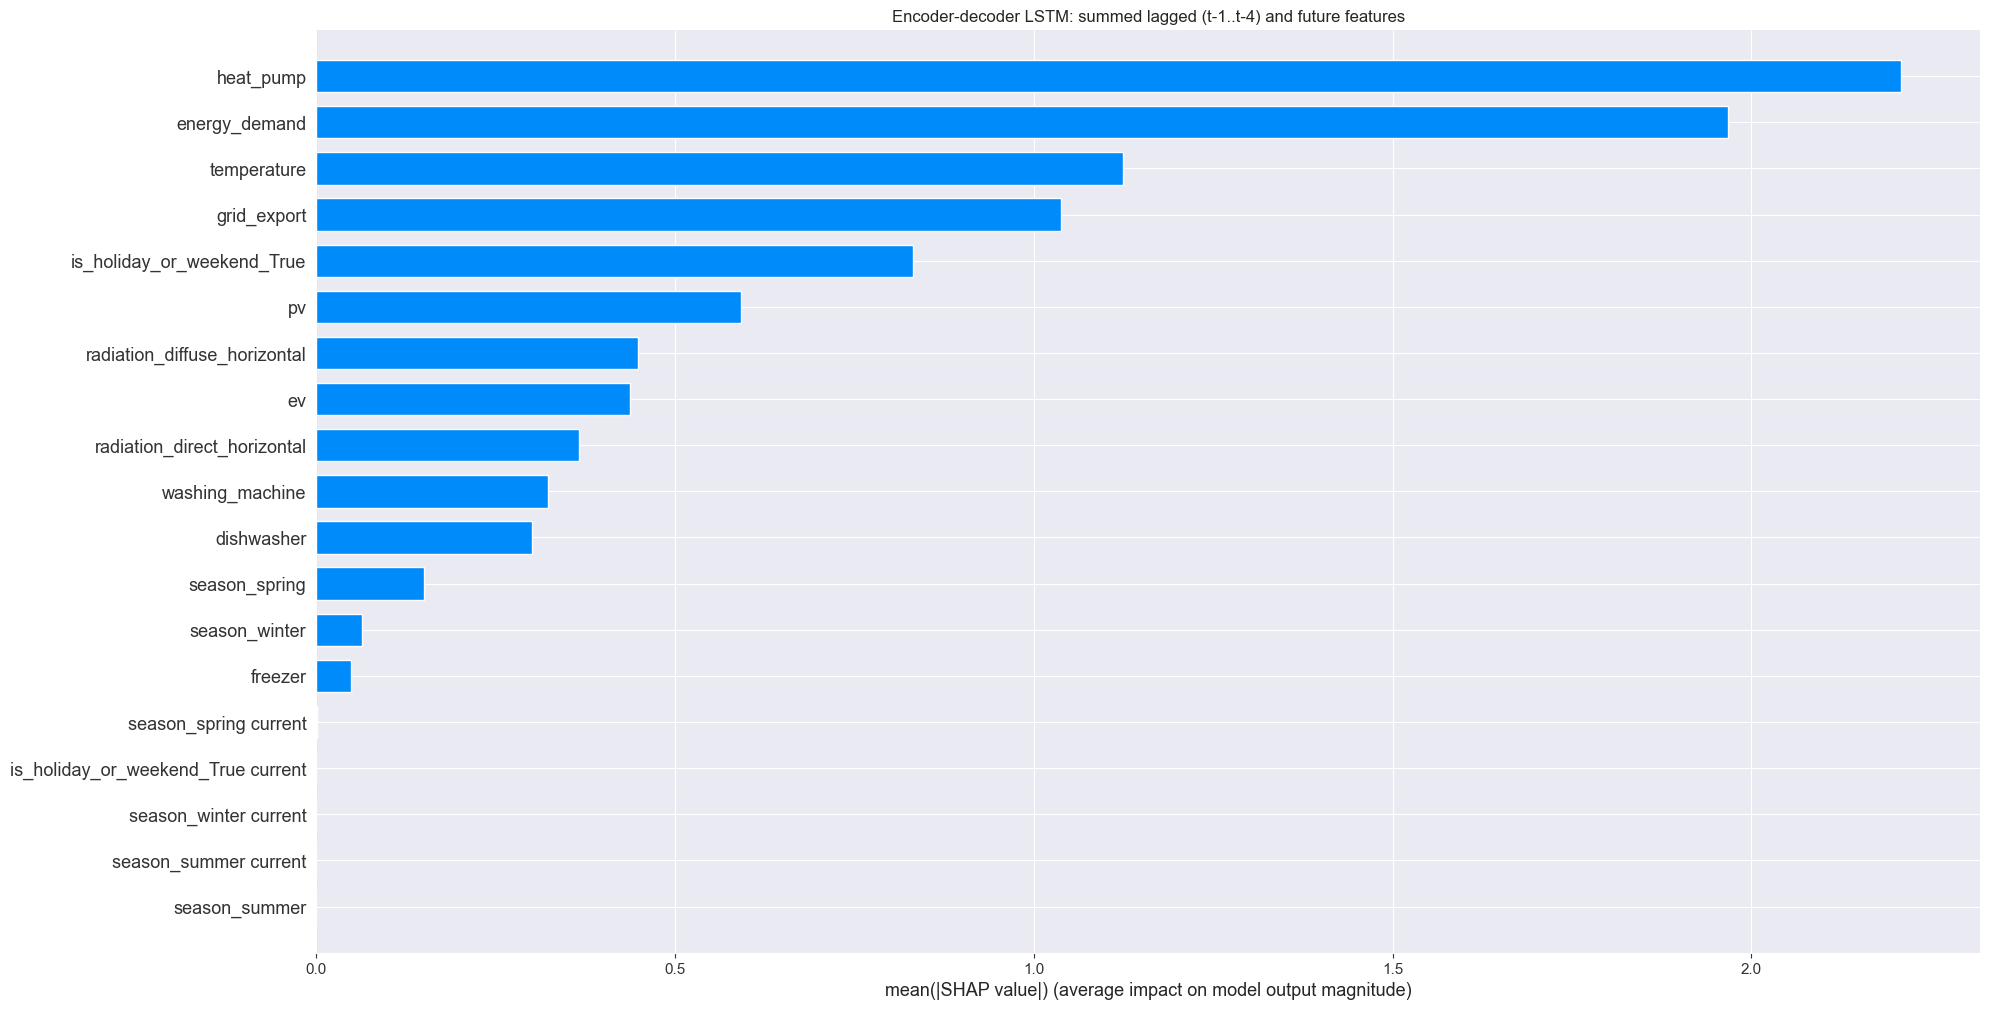

In [334]:
n_features = scaler.n_features_in_
future_feat_names = feat_names[-4:].tolist()
past_feat_names = feat_names[:-4].tolist()
all_feature_names = feat_names.tolist() + [f + " current" for f in future_feat_names]
rescale_factor = scaler.data_range_[0]

bg_p = Xp.astype(np.float32)
bg_f = Xf.astype(np.float32)
explainer = shap.GradientExplainer(model, [bg_p, bg_f])
shap_values = explainer.shap_values([bg_p, bg_f])

shap_values_squeezed = [sv.squeeze(-1) for sv in shap_values]

past_shap_summed = shap_values_squeezed[0].sum(axis=1)
future_shap = shap_values_squeezed[1].reshape(len(Xf), -1)

global_shap_kwh = (
    np.concatenate([past_shap_summed, future_shap], axis=1) * rescale_factor
)
global_data = np.concatenate([Xp[:, -1, :], Xf[:, 0, :]], axis=1)

shap.summary_plot(
    global_shap_kwh,
    global_data,
    feature_names=all_feature_names,
    plot_type="bar",
    show=False,
    plot_size=(20, 10),
)
plt.title("Encoder-decoder LSTM: summed lagged (t-1..t-4) and future features")
plt.show()

Here the feature importance behaves similarly to the attention LSTM, with recent time steps, heat pump energy production and weather features being the most influential. 

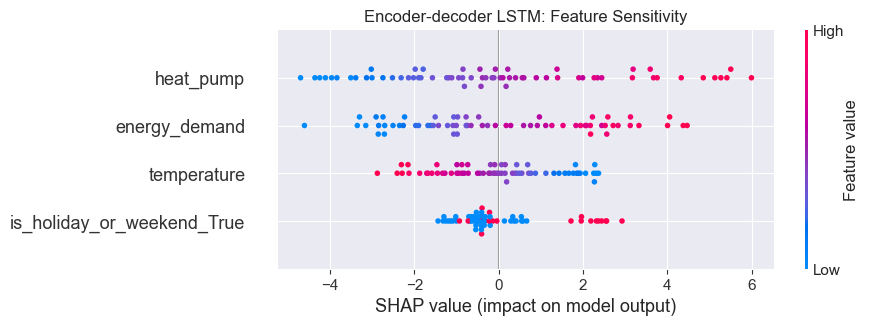

In [335]:
target_f = [
    "energy_demand",
    "heat_pump",
    "temperature",
    "is_holiday_or_weekend_True",
]
target_idx = [all_feature_names.index(f) for f in target_f if f in all_feature_names]

exp_beeswarm = shap.Explanation(
    values=global_shap_kwh[:, target_idx],
    data=global_data[:, target_idx],
    feature_names=target_f,
)
shap.plots.beeswarm(exp_beeswarm, show=False)
plt.title("Encoder-decoder LSTM: Feature Sensitivity")
plt.show()

Features showcased above have a clear impact on the prediction. Previous values of heat pump energy generation and previous values of the target variable are the main drivers of the prediction, which is consistent with the temporal dependencies in time series data. Higher temperature is associated with lower demand, which is consistent with the expected behavior of a energy demand time series where warmer weather reduces heating needs. On holidays, the household consistently shows higher demand, which is also expected as people may be away for work or have different routines.

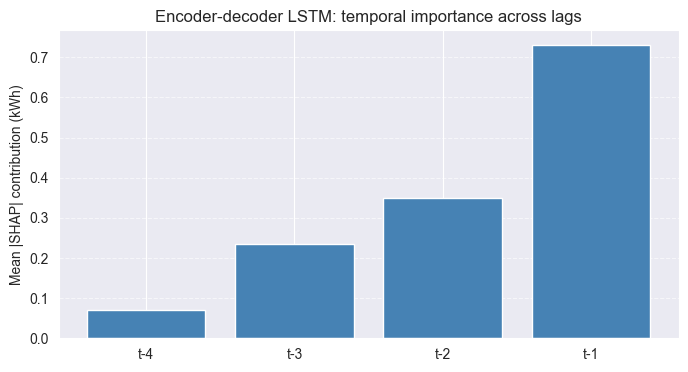

Lag importance (kWh): {'t-4': array([0.0707]), 't-3': array([0.2354]), 't-2': array([0.3489]), 't-1': array([0.7306])}


In [336]:
# Temporal importance across encoder lags (SHAP-based proxy for lag attention)
lag_abs_kwh = np.mean(np.abs(shap_values[0]) * rescale_factor, axis=(0, 2))
n_lags = shap_values[0].shape[1]
lag_labels = [f"t-{n_lags - i}" for i in range(n_lags)]

plt.figure(figsize=(8, 4))
plt.bar(lag_labels, lag_abs_kwh.ravel(), color="steelblue")
plt.title("Encoder-decoder LSTM: temporal importance across lags")
plt.ylabel("Mean |SHAP| contribution (kWh)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

print("Lag importance (kWh):", dict(zip(lag_labels, lag_abs_kwh.round(4))))

The attention decays as we go further back in time, which is consistent with the intuition that more recent time steps are more relevant for forecasting the next value in a time series. The model learns to focus on the most informative lags, which can improve forecasting accuracy compared to models that treat all past time steps equally.

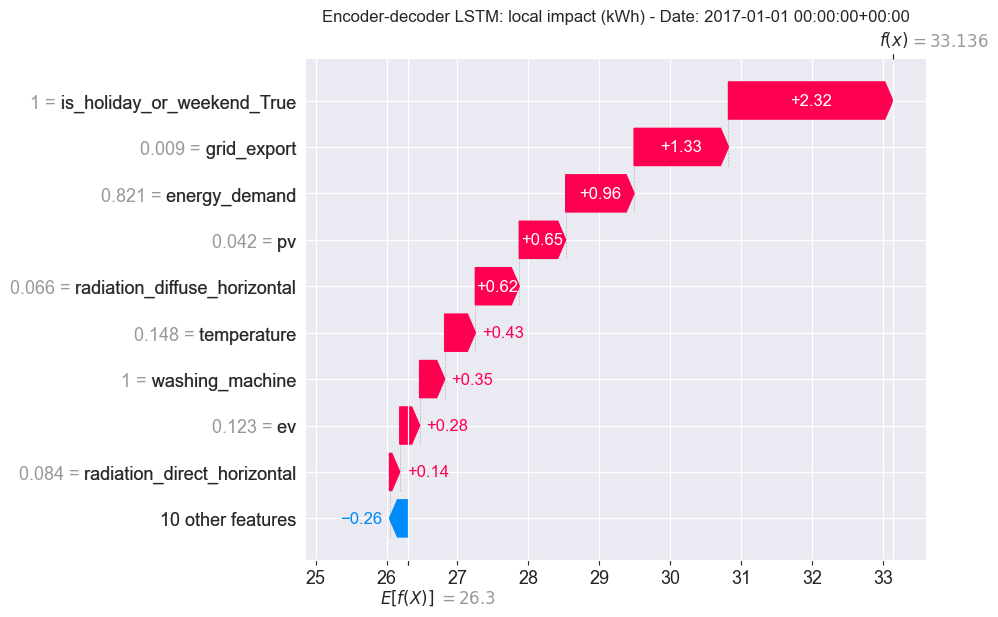

,0
date,2017-01-01 00:00:00+00:00
actual_kWh,30.293125
predicted_kWh,33.94281
error,-3.649685
norm_energy_demand,0.820711
norm_dishwasher,0.292096
norm_ev,0.122902
norm_freezer,0.0
norm_grid_export,0.009274
norm_heat_pump,0.851559


In [337]:
def rescale_val_keras(scaler, val, n_features, is_contribution=False):
    """Map scaled model values back to kWh."""
    dummy = np.zeros((1, n_features))
    dummy[0, 0] = val
    rescaled = scaler.inverse_transform(dummy)[0, 0]
    if is_contribution:
        zero_dummy = np.zeros((1, n_features))
        return rescaled - scaler.inverse_transform(zero_dummy)[0, 0]
    return rescaled


base_pred_raw = float(np.ravel(model.predict([bg_p, bg_f], verbose=0).mean())[0])
kwh_base = rescale_val_keras(scaler, base_pred_raw, n_features)

idx = 0
row = df_logged.iloc[idx]

exp_instance = shap.Explanation(
    values=global_shap_kwh[idx],
    base_values=kwh_base,
    data=global_data[idx],
    feature_names=all_feature_names,
)
plt.figure(figsize=(12, 5))
shap.plots.waterfall(exp_instance, show=False)
plt.title(f"Encoder-decoder LSTM: local impact (kWh) - Date: {row['date']}")
plt.show()

instance_df = df_logged.iloc[[idx]].copy()
for f_name, f_val in zip(all_feature_names, global_data[idx]):
    instance_df[f"norm_{f_name}"] = f_val
display(instance_df.T)

While the standard LSTM predicted 28.727 kWh, the Encoder-Decoder architecture is much more aggressive, predicting a significantly higher grid import of 33.144 kWh. For this time step, the Encoder-Decoder LSTM predicts a much higher grid import because it creates a compounding "perfect storm" explanation:
- High Domestic Load: It looks at a holiday/weekend, active appliances (washing_machine, ev), and high overall energy_demand as cumulative factors driving consumption up.
- Zero Local Generation: It looks at low temperature, low radiation, and near-zero pv generation, meaning the house cannot support itself.
- No Safety Net: It notes that grid_export is zero, confirming no excess energy is available.

In contrast to previous LSTM architecture, encoder-decoder LSTM uses a bottleneck layer to compress the input sequence (encoder) before step-by-step generating the sequence prediction (decoder). This architecture is often much better at capturing multi-step dependencies and cumulative energy states over time. The result here is an interpretation that feels highly logical and additive, whereas the standard LSTM captured more localized, potentially noisy correlations (e.g.
 the washing machine reducing imports).

training temp range: 29.86 C
0.33 scaled shift: 9.86 C


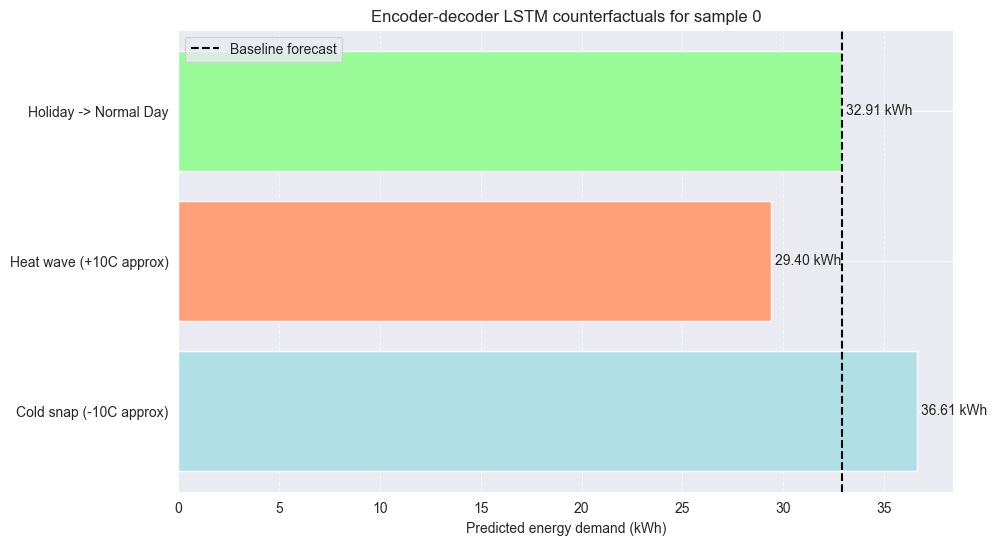

{'Cold snap (-10C approx)': np.float64(36.61307669169679),
 'Heat wave (+10C approx)': np.float64(29.39596097921307),
 'Holiday -> Normal Day': np.float64(32.90843637978012)}

In [338]:
def run_counterfactual_scenarios_keras(
    model, Xp, Xf, scaler, feat_names, past_names, future_names, sample_idx=0
):
    """Run what-if scenarios for a Keras encoder-decoder model."""
    n_features = scaler.n_features_in_
    orig_xp = Xp[sample_idx : sample_idx + 1].astype(np.float32).copy()
    orig_xf = Xf[sample_idx : sample_idx + 1].astype(np.float32).copy()

    base_raw = float(np.ravel(model.predict([orig_xp, orig_xf], verbose=0))[0])
    base_pred = rescale_val_keras(scaler, base_raw, n_features)

    scenarios = {}

    temp_idx = list(feat_names).index("temperature")
    temp_range = scaler.data_range_[temp_idx]
    physical_delta = 0.33 * temp_range
    print(f"training temp range: {temp_range:.2f} C")
    print(f"0.33 scaled shift: {physical_delta:.2f} C")

    # Scenario 1: colder period over all encoder lags
    xp_cold = orig_xp.copy()
    xp_cold[:, :, temp_idx] -= 0.33
    pred_cold_raw = float(np.ravel(model.predict([xp_cold, orig_xf], verbose=0))[0])
    scenarios["Cold snap (-10C approx)"] = rescale_val_keras(
        scaler, pred_cold_raw, n_features
    )

    # Scenario 2: hotter period over all encoder lags
    xp_heat = orig_xp.copy()
    xp_heat[:, :, temp_idx] += 0.33
    pred_heat_raw = float(np.ravel(model.predict([xp_heat, orig_xf], verbose=0))[0])
    scenarios["Heat wave (+10C approx)"] = rescale_val_keras(
        scaler, pred_heat_raw, n_features
    )

    # Scenario 3: flip holiday/weekend flag for first future step
    holiday_idx = future_names.index("is_holiday_or_weekend_True")
    xf_flip = orig_xf.copy()
    is_holiday = xf_flip[0, 0, holiday_idx] > 0.5
    xf_flip[0, 0, holiday_idx] = 0.0 if is_holiday else 1.0
    label = "Normal Day -> Holiday" if not is_holiday else "Holiday -> Normal Day"
    pred_flip_raw = float(np.ravel(model.predict([orig_xp, xf_flip], verbose=0))[0])
    scenarios[label] = rescale_val_keras(scaler, pred_flip_raw, n_features)

    names = list(scenarios.keys())
    values = list(scenarios.values())

    plt.figure(figsize=(10, 6))
    bars = plt.barh(names, values, color=["powderblue", "lightsalmon", "palegreen"])
    plt.axvline(base_pred, color="black", linestyle="--", label="Baseline forecast")
    plt.bar_label(bars, padding=3, fmt="%.2f kWh")
    plt.title(f"Encoder-decoder LSTM counterfactuals for sample {sample_idx}")
    plt.xlabel("Predicted energy demand (kWh)")
    plt.legend()
    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.show()

    return scenarios


run_counterfactual_scenarios_keras(
    model,
    Xp,
    Xf,
    scaler,
    feat_names,
    past_feat_names,
    future_feat_names,
    sample_idx=0,
)

What-if scenarios show that the model is sensitive to changes in key features. It behaves in a logical way, with predictions increasing when we simulate a colder day (lower temperature) or higher appliance usage (washing machine on), and decreasing when we simulate a warmer day or no appliance usage. This sensitivity to input features is consistent with the SHAP analysis and indicates that the model is capturing meaningful relationships in the data rather than relying on spurious correlations.

## 8. Temporal Fusion Transformer

### Method overview
The Temporal Fusion Transformer (TFT) is a state-of-the-art architecture that combines recurrent layers with attention mechanisms to capture both short-term and long-term dependencies in time series data. It encompasses previouusly discussed LSTM architectures into one and builds on top of them with a more flexible and powerful attention mechanism that can capture complex temporal patterns and interactions between features. It can handle static covariates, known future inputs, and past observed values, making it highly flexible for forecasting tasks. The TFT also provides interpretability through feature importance and attention weights, allowing us to understand which features and time steps are driving the predictions. 

In [371]:
run_id = "1et4nbos"

api = wandb.Api()
run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
config = run.config

artifact = api.artifact(
    f'{ENTITY}/{PROJECT}/trained_model_{config["wandb"]["run_name"]}:latest'
)
artifact_dir = artifact.download()

table_artifact = [a for a in run.logged_artifacts() if "predictions" in a.name][0]
df_logged = table_artifact.get("predictions").get_dataframe()

scaler = joblib.load(os.path.join(artifact_dir, "scaler.joblib"))
state_dict = torch.load(os.path.join(artifact_dir, "TFT.pth"), map_location="cpu")

parent_dir = os.path.dirname(os.getcwd())
train_df = load_data(os.path.join(parent_dir, config["data"]["train_path"]))
test_df = load_data(os.path.join(parent_dir, config["data"]["test_path"]))

train, test, cnct = preprocess_data_tft(train_df, test_df)

wandb:   2 of 2 files downloaded.  
wandb:   1 of 1 files downloaded.  


In [381]:
# 1. Instantiate the TimeSeriesDataSet
training = TimeSeriesDataSet(
    train,
    time_idx="day",
    target="energy_demand",
    group_ids=["group_id"],
    max_encoder_length=2,
    max_prediction_length=1,
    time_varying_unknown_reals=[
        "energy_demand",
        "dishwasher",
        "ev",
        "freezer",
        "grid_export",
        "heat_pump",
        "washing_machine",
        "temperature",
        "radiation_direct_horizontal",
        "radiation_diffuse_horizontal",
    ],
    time_varying_known_categoricals=["season", "is_holiday_or_weekend"],
    target_normalizer=scaler,
)

# 2. Instantiate and load Temporal Fusion Transformer

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=config["training"]["lr"],
    hidden_size=config["model"]["network_params"]["hidden_size"],
    attention_head_size=config["model"]["network_params"]["attention_head_size"],
    dropout=config["model"]["network_params"]["dropout"],
    hidden_continuous_size=config["model"]["network_params"]["hidden_continuous_size"],
    loss=QuantileLoss(),
)
tft.load_state_dict(state_dict)
tft.eval()

# 3. Prepare validation dataloader and get batch
validation = TimeSeriesDataSet.from_dataset(
    training,
    cnct,
    predict=False,
    min_prediction_idx=test.at[0, "day"],
    stop_randomization=True,
)

x, y = next(iter(validation.to_dataloader(train=False, batch_size=1)))

raw_preds = tft.predict(validation, mode="raw", return_x=True)

preds = raw_preds.output.prediction
pred_1step = preds[:, 0].detach().cpu().numpy()
lower = pred_1step[:, 0]
upper = pred_1step[:, -1]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


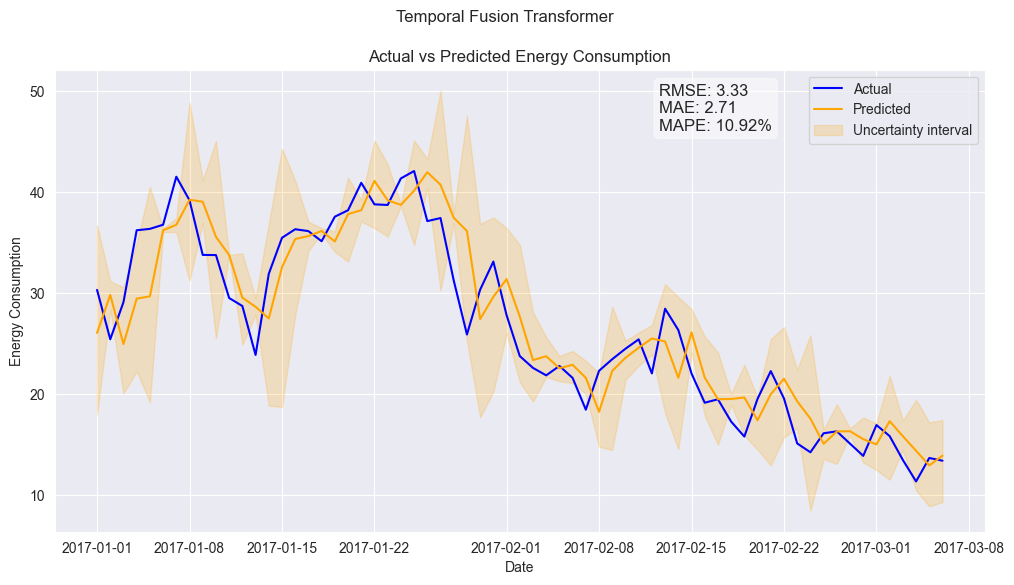

In [373]:
plt.figure(figsize=(12, 6))
plt.plot(df_logged["date"], df_logged["actual_kWh"], label="Actual", color="blue")
plt.plot(
    df_logged["date"], df_logged["predicted_kWh"], label="Predicted", color="orange"
)
plt.fill_between(
    df_logged["date"],
    lower,
    upper,
    alpha=0.2,
    color="orange",
    label="Uncertainty interval",
)
rmse = np.sqrt(np.mean((df_logged["actual_kWh"] - df_logged["predicted_kWh"]) ** 2))
mae = np.mean(np.abs(df_logged["actual_kWh"] - df_logged["predicted_kWh"]))
mape = (
    np.mean(
        np.abs(
            (df_logged["actual_kWh"] - df_logged["predicted_kWh"])
            / df_logged["actual_kWh"]
        )
    )
    * 100
)
plt.text(
    0.65,
    0.97,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nMAPE: {mape:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.5),
)
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")
plt.suptitle("Temporal Fusion Transformer")
plt.legend(loc="upper right")
plt.show()

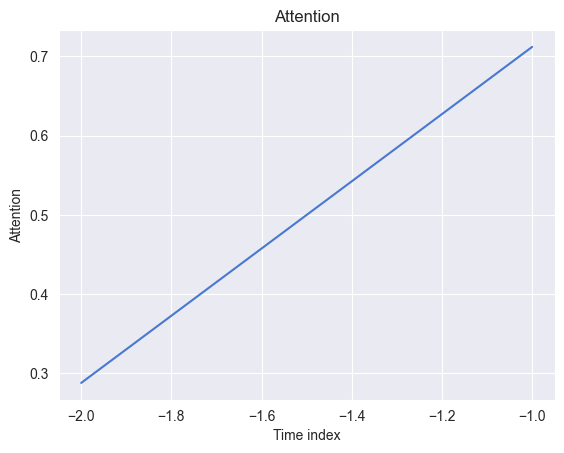

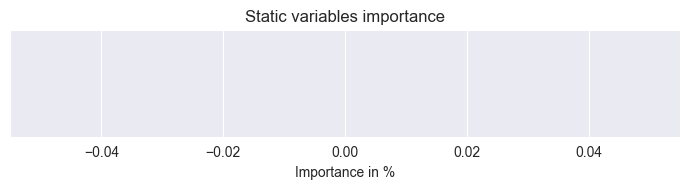

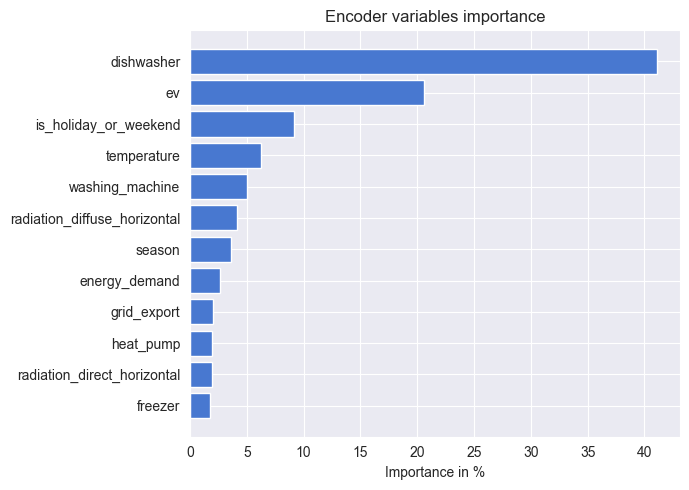

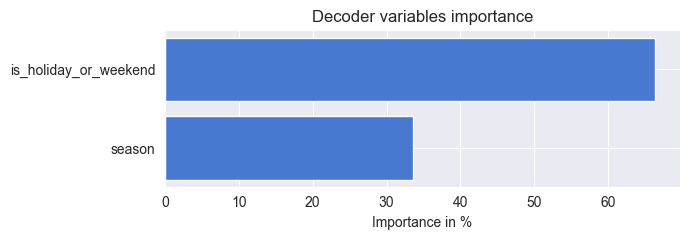

In [374]:
interpretation = tft.interpret_output(raw_preds.output, reduction="sum")
tft.plot_interpretation(interpretation)
plt.tight_layout()
plt.show()

The attention is distributed in the same way as simple attention LSTM, with the most recent time steps being the most important for the prediction. The data did not contain any static variables. For the feature importance it behaves differently than the previous LSTM models, with the most important features being appliances rather than weather features. This suggests that the TFT is placing more emphasis on the current operational state of the household and recent energy usage patterns, which may provide a more accurate and context-aware forecast compared to the previous LSTM models. The attention mechanism in TFT allows it to capture complex interactions between features and time steps, which can lead to improved forecasting performance.

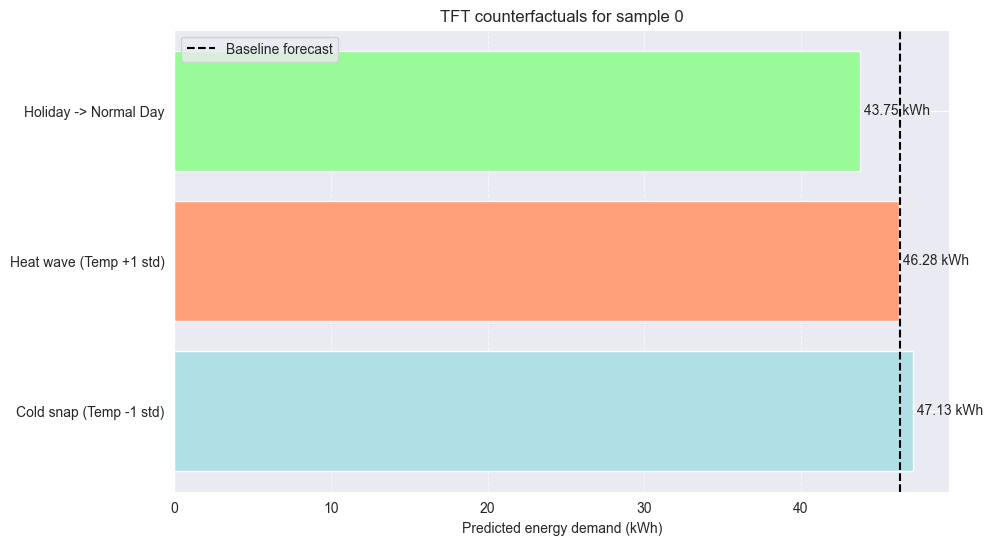

{'Cold snap (Temp -1 std)': 47.127952575683594,
 'Heat wave (Temp +1 std)': 46.27848815917969,
 'Holiday -> Normal Day': 43.74740982055664}

In [382]:
# Counterfactual what-if scenarios
def run_counterfactual_scenarios_tft(model, x_dict, scaler, sample_idx=0):
    x_sample = {
        k: v[sample_idx : sample_idx + 1].clone() if isinstance(v, torch.Tensor) else v
        for k, v in x_dict.items()
    }

    with torch.no_grad():
        base_raw = model(x_sample).prediction[0, 0, 3].item()
    base_pred = scaler.inverse_transform(torch.tensor(base_raw)).item()

    scenarios = {}

    # Scenario 1: Cold snap (-1 standard deviation on temperature)
    x_cold = {
        k: v.clone() if isinstance(v, torch.Tensor) else v for k, v in x_sample.items()
    }
    x_cold["encoder_cont"][:, :, None] -= 1.0
    with torch.no_grad():
        pred_cold_raw = model(x_cold).prediction[0, 0, 3].item()
    scenarios["Cold snap (Temp -1 std)"] = scaler.inverse_transform(
        torch.tensor(pred_cold_raw)
    ).item()

    # Scenario 2: Heat wave (+1 standard deviation on temperature)
    x_heat = {
        k: v.clone() if isinstance(v, torch.Tensor) else v for k, v in x_sample.items()
    }
    x_heat["encoder_cont"][:, :, None] += 1.0
    with torch.no_grad():
        pred_heat_raw = model(x_heat).prediction[0, 0, 3].item()
    scenarios["Heat wave (Temp +1 std)"] = scaler.inverse_transform(
        torch.tensor(pred_heat_raw)
    ).item()

    # Scenario 3: Flip holiday/weekend flag
    x_flip = {
        k: v.clone() if isinstance(v, torch.Tensor) else v for k, v in x_sample.items()
    }
    is_holiday = x_flip["decoder_cat"][0, 0, 1].item() > 0.5
    x_flip["decoder_cat"][0, 0, 1] = 0.0 if is_holiday else 1.0
    label = "Normal Day -> Holiday" if not is_holiday else "Holiday -> Normal Day"
    with torch.no_grad():
        pred_flip_raw = model(x_flip).prediction[0, 0, 3].item()
    scenarios[label] = scaler.inverse_transform(torch.tensor(pred_flip_raw)).item()

    names = list(scenarios.keys())
    values = list(scenarios.values())

    plt.figure(figsize=(10, 6))
    bars = plt.barh(names, values, color=["powderblue", "lightsalmon", "palegreen"])
    plt.axvline(base_pred, color="black", linestyle="--", label="Baseline forecast")
    plt.bar_label(bars, padding=3, fmt="%.2f kWh")
    plt.title(f"TFT counterfactuals for sample {sample_idx}")
    plt.xlabel("Predicted energy demand (kWh)")
    plt.legend()
    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.show()

    return scenarios


run_counterfactual_scenarios_tft(tft, x, scaler, sample_idx=0)

The impact of temperature and holiday which were one the most relevant features in the previous LSTM models is much less pronounced in the TFT, which is in line with what the feature importance plot shows. This suggests that the TFT is relying more on the current state of appliances and recent energy usage patterns rather than external factors like weather and holidays, which may indicate that it has learned to capture the underlying dynamics of the household's energy consumption more effectively than the previous LSTM models.